<!-- Cell purpose: Introduce the embryonated treatment summary notebook. -->

# Embryonated Treatment Summary (`analysis_sumup_embryonated.ipynb`)

This notebook summarizes embryonated egg treatment outcomes across 800nm, SHG, and UVC datasets,
using the same processing conventions as the modality-specific notebooks.

Rules applied:
- Main readout: `dt_motion_stop_h = t_motion_stop_h - t_start_h`
- Still moving at end-of-footage: `t_motion_stop_h = NA` and `death_mode = NA`
- Exclude from all analyses: `flags` contains `no_larvae`
- In-egg stop cohort: exclude `death_after_hatch`
- Max observation time: 700 h


In [15]:
# Define the treatment order and inclusion rules for the summary analysis

from pathlib import Path
import re

import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from matplotlib.ticker import MultipleLocator
from scipy import stats

try:
    from lifelines import KaplanMeierFitter
    from lifelines.statistics import logrank_test, multivariate_logrank_test
except Exception as exc:
    KaplanMeierFitter = None
    logrank_test = None
    multivariate_logrank_test = None
    print(f"lifelines import failed: {exc}. Step 8 / 9C requires `pip install lifelines`.")

try:
    from IPython.display import display
except Exception:
    def display(x):
        print(x)

sns.set_theme(style="whitegrid", context="talk")

CSV_PATH = "master_csv/02_master_embryonated.csv"

CONTROL_LABELS = [
    "400-SHG-40mW-control",
    "800-control-330mW",
    "400-SHG-20mW-control",
]

GROUPS_800 = [
    "800-pulsed-330mW-120s",
    "800-pulsed-330mW-60s",
    "800-cw-330mW-120s",
]

GROUPS_SHG = [
    "400-SHG-10mW-5s",
    "400-SHG-10mW-10s",
    "400-SHG-15mW-5s",
    "400-SHG-15mW-10s",
    "400-SHG-20mW-10s",
    "400-SHG-30mW-5s",
    "400-SHG-30mW-10s",
    "400-SHG-40mW-5s",
    "400-SHG-40mW-10s",
    "400-SHG-40mW-30s",
]

GROUPS_UVC = [
    "UVC-6W-600s",
    "UVC-6W-300s",
    "UVC-6W-180s",
    "UVC-6W-120s",
    "UVC-6W-60s",
    "UVC-6W-30s",
]

TREATMENT_GROUP_ORDER = [*GROUPS_800, *GROUPS_SHG, *GROUPS_UVC]
ALL_GROUP_ORDER = ["Control (pooled)", *TREATMENT_GROUP_ORDER]

SHG_EXCLUDE_NON_MOTILE = {
    "400-SHG-40mW-30s",
    "400-SHG-40mW-10s",
    "400-SHG-40mW-5s",
    "400-SHG-30mW-10s",
    "400-SHG-30mW-5s",
    "400-SHG-20mW-10s",
}
SHG_INCLUDED = [g for g in GROUPS_SHG if g not in SHG_EXCLUDE_NON_MOTILE]

UVC_EXCLUDE_PLOT_KM = {"UVC-6W-600s"}
UVC_PLOT_KM_INCLUDED = [g for g in GROUPS_UVC if g not in UVC_EXCLUDE_PLOT_KM]
UVC_STATS_INCLUDED = list(GROUPS_UVC)

BOX_CANDIDATE_GROUPS = [*GROUPS_800, *SHG_INCLUDED, *UVC_PLOT_KM_INCLUDED]
KM_CANDIDATE_GROUPS = ["Control (pooled)", *GROUPS_800, *SHG_INCLUDED, *UVC_PLOT_KM_INCLUDED]
STATS_TREATED_CANDIDATES = [*GROUPS_800, *SHG_INCLUDED, *UVC_STATS_INCLUDED]

DEATH_MODES = ["apoptotic_like", "necrotic_like", "uncertain"]
DEATH_MODE_DISPLAY = {
    "apoptotic_like": "Vacuolated (apoptosis-like)",
    "necrotic_like": "Lytic (necrosis-like)",
    "uncertain": "Indeterminate/hatched",
    "uncertein": "Indeterminate/hatched",
}
TERMINAL_PHENOTYPE_LABEL = "Terminal phenotype"
DEATH_MODE_DISPLAY_ORDER = [DEATH_MODE_DISPLAY[m] for m in DEATH_MODES]
DEATH_MODE_PALETTE = {
    "Vacuolated (apoptosis-like)": "#59a14f",
    "Lytic (necrosis-like)": "#e15759",
    "Indeterminate/hatched": "#4e79a7",
}
MAX_FOOTAGE_H = 700.0

OUT_BASE = Path("cross-modality/embryonated")
PLOTS_DIR = OUT_BASE / "plots"
TABLES_DIR = OUT_BASE / "tables"
PLOTS_DIR.mkdir(parents=True, exist_ok=True)
TABLES_DIR.mkdir(parents=True, exist_ok=True)


In [16]:
# Define helper functions for file lookup and data preparation

def resolve_csv_path(raw_path: str) -> Path:
    raw = Path(raw_path)
    stripped = Path(str(raw_path).replace("LIA-STH-Repo/", "", 1))

    start = Path.cwd().resolve()
    search_bases = [start, *start.parents]

    candidates = [raw, stripped]
    for base in search_bases:
        candidates.append(base / raw)
        candidates.append(base / stripped)

    seen = set()
    for cand in candidates:
        key = str(cand)
        if key in seen:
            continue
        seen.add(key)
        if cand.exists():
            return cand.resolve()

    raise FileNotFoundError(f"CSV not found. Tried: {[str(c) for c in candidates]}")


def to_snake_or_nan(x):
    if pd.isna(x):
        return np.nan
    s = str(x).strip().lower()
    if s in {"", "na", "none"}:
        return np.nan
    s = re.sub(r"[^0-9a-zA-Z]+", "_", s)
    s = re.sub(r"_+", "_", s).strip("_")
    return s if s else np.nan


def normalize_flags(x):
    if pd.isna(x):
        return np.nan

    raw = str(x).strip()
    if raw == "" or raw.lower() in {"na", "none"}:
        return np.nan

    parts = [to_snake_or_nan(part) for part in raw.split(";")]
    parts = [p for p in parts if pd.notna(p)]
    if not parts:
        return np.nan
    return ";".join(parts)


def has_flag(series: pd.Series, token: str) -> pd.Series:
    token_norm = to_snake_or_nan(token)
    if pd.isna(token_norm):
        return pd.Series(False, index=series.index)
    pattern = rf"(?:^|;){re.escape(token_norm)}(?:$|;)"
    return series.fillna("").str.contains(pattern, regex=True)


def pct(n: int, d: int) -> float:
    return (100.0 * n / d) if d else np.nan


def median_iqr(series: pd.Series):
    vals = series.dropna().astype(float)
    if vals.empty:
        return np.nan, np.nan, np.nan
    return float(vals.median()), float(vals.quantile(0.25)), float(vals.quantile(0.75))


def modality_from_group(g: str) -> str:
    s = str(g)
    if s.startswith("800-"):
        return "800nm"
    if s.startswith("400-SHG"):
        return "SHG"
    if s.startswith("UVC-"):
        return "UVC"
    return "Control"


def build_group_palette(groups):
    palette = {}

    palette_800 = {
        "800-pulsed-330mW-120s": "#e15759",
        "800-pulsed-330mW-60s": "#4e79a7",
        "800-cw-330mW-120s": "#76b7b2",
    }
    palette.update(palette_800)

    shg_colors = sns.color_palette("tab10", n_colors=max(len(GROUPS_SHG), 3))
    for i, g in enumerate(GROUPS_SHG):
        palette[g] = shg_colors[i % len(shg_colors)]

    uvc_colors = sns.color_palette("flare", n_colors=max(len(GROUPS_UVC), 3))
    for i, g in enumerate(GROUPS_UVC):
        palette[g] = uvc_colors[i % len(uvc_colors)]

    palette["Control (pooled)"] = "#9c755f"

    return {g: palette.get(g, "#999999") for g in groups}

def p_to_sig(p: float) -> str:
    if pd.isna(p):
        return "NA"
    if p < 0.001:
        return "***"
    if p < 0.01:
        return "**"
    if p < 0.05:
        return "*"
    return "ns"



In [17]:
# Load and clean source table

csv_file = resolve_csv_path(CSV_PATH)
df = pd.read_csv(csv_file)

required_cols = [
    "egg_uid",
    "exp_label",
    "start_date",
    "control",
    "t_start_h",
    "t_motion_stop_h",
    "death_mode",
    "flags",
]
missing_cols = [c for c in required_cols if c not in df.columns]
if missing_cols:
    raise KeyError(f"Missing required columns: {missing_cols}")

unnamed = [c for c in df.columns if c.lower().startswith("unnamed")]
if unnamed:
    df = df.drop(columns=unnamed)

if "well_#" in df.columns:
    df = df.rename(columns={"well_#": "well_id"})

text_cols = df.select_dtypes(include=["object", "string"]).columns.tolist()
for col in text_cols:
    s = df[col].astype("string").str.strip()
    s = s.replace({"NA": pd.NA, "na": pd.NA, "": pd.NA, "None": pd.NA, "none": pd.NA}, regex=False)
    df[col] = s

df["start_date"] = pd.to_datetime(df["start_date"], errors="coerce")
for col in ["system", "regime", "death_mode"]:
    if col in df.columns:
        df[col] = df[col].map(to_snake_or_nan)

if "death_mode" in df.columns:
    df["death_mode"] = df["death_mode"].replace({"uncertein": "uncertain"})

if "flags" in df.columns:
    df["flags"] = df["flags"].map(normalize_flags)

df["exp_label_norm"] = df["exp_label"].map(to_snake_or_nan)

for col in [
    "control",
    "wl_nm",
    "power_mW",
    "irradiance_mW_cm2",
    "exposure_s",
    "fluence_J_cm2",
    "t_start_h",
    "t_motion_stop_h",
]:
    if col in df.columns:
        df[col] = pd.to_numeric(df[col], errors="coerce")

df["dt_motion_stop_h"] = df["t_motion_stop_h"] - df["t_start_h"]

map_without_control = {}
for g in TREATMENT_GROUP_ORDER:
    if g.startswith("UVC-") and g.endswith("s"):
        map_without_control[g] = [g, g[:-1]]
    else:
        map_without_control[g] = [g]

GROUP_TO_LABELS = {
    "Control (pooled)": CONTROL_LABELS,
    **map_without_control,
}

group_frames = []
for group_name, labels in GROUP_TO_LABELS.items():
    label_norm = {to_snake_or_nan(x) for x in labels}
    mask = df["exp_label_norm"].isin(label_norm)
    if group_name == "Control (pooled)":
        mask &= (df["control"] == 1)

    g = df.loc[mask].copy()
    g["analysis_group"] = group_name
    group_frames.append(g)

analysis_df = pd.concat(group_frames, ignore_index=True)
analysis_df["analysis_group"] = pd.Categorical(analysis_df["analysis_group"], categories=ALL_GROUP_ORDER, ordered=True)
analysis_df["modality"] = analysis_df["analysis_group"].map(modality_from_group)

analysis_df["flag_no_larvae"] = has_flag(analysis_df["flags"], "no_larvae")
analysis_df["flag_death_after_hatch"] = has_flag(analysis_df["flags"], "death_after_hatch")
analysis_df["flag_exit_egg"] = has_flag(analysis_df["flags"], "exit_egg")
analysis_df["flag_terminal_twitching"] = has_flag(analysis_df["flags"], "terminal_twitching")

analysis_df["is_analyzed"] = ~analysis_df["flag_no_larvae"]
analysis_df["is_continued_motion"] = (
    analysis_df["is_analyzed"]
    & analysis_df["t_motion_stop_h"].isna()
    & analysis_df["death_mode"].isna()
)
analysis_df["is_stopped_in_egg"] = (
    analysis_df["is_analyzed"]
    & analysis_df["t_motion_stop_h"].notna()
    & (~analysis_df["flag_death_after_hatch"])
    & (analysis_df["t_motion_stop_h"] <= MAX_FOOTAGE_H)
)
analysis_df["is_event_survival"] = (
    analysis_df["is_analyzed"]
    & analysis_df["dt_motion_stop_h"].notna()
    & (analysis_df["dt_motion_stop_h"] <= MAX_FOOTAGE_H)
)
analysis_df["duration_survival_h"] = np.where(
    analysis_df["is_event_survival"], analysis_df["dt_motion_stop_h"], MAX_FOOTAGE_H
)
analysis_df["duration_survival_h"] = analysis_df["duration_survival_h"].astype(float).clip(lower=0, upper=MAX_FOOTAGE_H)

print(f"Loaded: {csv_file}")
print(f"Rows in full master table: {len(df)}")
print(f"Rows in analysis subset (control + selected treatments): {len(analysis_df)}")

group_counts_raw = (
    analysis_df.groupby("analysis_group", observed=False)
    .size()
    .rename("n_raw")
    .reset_index()
)

group_counts_analyzed = (
    analysis_df[analysis_df["is_analyzed"]]
    .groupby("analysis_group", observed=False)
    .size()
    .rename("n_after_no_larvae_exclusion")
    .reset_index()
)

counts_view = group_counts_raw.merge(group_counts_analyzed, on="analysis_group", how="left")
counts_view["n_after_no_larvae_exclusion"] = counts_view["n_after_no_larvae_exclusion"].fillna(0).astype(int)
display(counts_view)

missing_treatments = counts_view.loc[
    counts_view["analysis_group"].isin(TREATMENT_GROUP_ORDER)
    & (counts_view["n_raw"] == 0),
    "analysis_group",
].astype(str).tolist()
if missing_treatments:
    print("Note: requested treatment labels with zero rows in this master table:", ", ".join(missing_treatments))


Loaded: /Users/arkadi/Desktop/lia-sth/exp_data/data_analysis/master_csv/02_master_embryonated.csv
Rows in full master table: 811
Rows in analysis subset (control + selected treatments): 775


,analysis_group,n_raw,n_after_no_larvae_exclusion
0,Control (pooled),97,97
1,800-pulsed-330mW-120s,24,24
2,800-pulsed-330mW-60s,32,31
3,800-cw-330mW-120s,23,22
4,400-SHG-10mW-5s,36,36
5,400-SHG-10mW-10s,36,36
6,400-SHG-15mW-5s,38,38
7,400-SHG-15mW-10s,38,38
8,400-SHG-20mW-10s,37,37
9,400-SHG-30mW-5s,39,39


In [18]:
# Data QC and overview table

qc_rows = []
for group in ALL_GROUP_ORDER:
    sub = analysis_df.loc[analysis_df["analysis_group"] == group].copy()
    sub_an = sub.loc[sub["is_analyzed"]].copy()

    n_total = int(len(sub))
    n_excl_no_larvae = int(sub["flag_no_larvae"].sum())
    n_analyzed = int(len(sub_an))

    row = {
        "group": group,
        "modality": modality_from_group(group),
        "n_total": n_total,
        "n_excluded_no_larvae": n_excl_no_larvae,
        "pct_excluded_no_larvae": round(pct(n_excl_no_larvae, n_total), 1),
        "n_analyzed": n_analyzed,
    }

    for mode in DEATH_MODES:
        n_mode = int((sub_an["death_mode"] == mode).sum())
        row[f"n_{mode}"] = n_mode
        row[f"pct_{mode}"] = round(pct(n_mode, n_analyzed), 1)

    for flag in ["death_after_hatch", "exit_egg", "terminal_twitching"]:
        n_flag = int(has_flag(sub_an["flags"], flag).sum())
        row[f"n_flag_{flag}"] = n_flag
        row[f"pct_flag_{flag}"] = round(pct(n_flag, n_analyzed), 1)

    qc_rows.append(row)

qc_overview_df = pd.DataFrame(qc_rows)
qc_overview_display_df = qc_overview_df.rename(
    columns={
        **{f"n_{mode}": f"n_{DEATH_MODE_DISPLAY.get(mode, mode)}" for mode in DEATH_MODES},
        **{f"pct_{mode}": f"pct_{DEATH_MODE_DISPLAY.get(mode, mode)}" for mode in DEATH_MODES},
    }
)
display(qc_overview_display_df)

qc_overview_display_df.to_csv(TABLES_DIR / "sumup_embryonated_qc_overview.csv", index=False)


,group,modality,n_total,n_excluded_no_larvae,pct_excluded_no_larvae,n_analyzed,n_Vacuolated (apoptosis-like),pct_Vacuolated (apoptosis-like),n_Lytic (necrosis-like),pct_Lytic (necrosis-like),n_Indeterminate/hatched,pct_Indeterminate/hatched,n_flag_death_after_hatch,pct_flag_death_after_hatch,n_flag_exit_egg,pct_flag_exit_egg,n_flag_terminal_twitching,pct_flag_terminal_twitching
0,Control (pooled),Control,97,0,0.0,97,0,0.0,3,3.1,12,12.4,9,9.3,1,1.0,0,0.0
1,800-pulsed-330mW-120s,800nm,24,0,0.0,24,2,8.3,17,70.8,4,16.7,4,16.7,0,0.0,0,0.0
2,800-pulsed-330mW-60s,800nm,32,1,3.1,31,0,0.0,2,6.5,4,12.9,0,0.0,0,0.0,0,0.0
3,800-cw-330mW-120s,800nm,23,1,4.3,22,0,0.0,1,4.5,0,0.0,0,0.0,0,0.0,0,0.0
4,400-SHG-10mW-5s,SHG,36,0,0.0,36,0,0.0,18,50.0,11,30.6,11,30.6,18,50.0,0,0.0
5,400-SHG-10mW-10s,SHG,36,0,0.0,36,2,5.6,21,58.3,8,22.2,8,22.2,23,63.9,0,0.0
6,400-SHG-15mW-5s,SHG,38,0,0.0,38,34,89.5,1,2.6,2,5.3,1,2.6,28,73.7,0,0.0
7,400-SHG-15mW-10s,SHG,38,0,0.0,38,38,100.0,0,0.0,0,0.0,0,0.0,35,92.1,0,0.0
8,400-SHG-20mW-10s,SHG,37,0,0.0,37,37,100.0,0,0.0,0,0.0,0,0.0,0,0.0,0,0.0
9,400-SHG-30mW-5s,SHG,39,0,0.0,39,39,100.0,0,0.0,0,0.0,0,0.0,1,2.6,0,0.0


In [19]:
# Motion cessation analysis (each treatment separately)

motion_rows = []
for group in TREATMENT_GROUP_ORDER:
    sub = analysis_df.loc[(analysis_df["analysis_group"] == group) & (analysis_df["is_analyzed"])].copy()

    n_total = int(len(sub))
    n_cont = int(sub["is_continued_motion"].sum())

    sub_stopped_in_egg = sub.loc[
        sub["is_stopped_in_egg"] & sub["dt_motion_stop_h"].notna(),
        "dt_motion_stop_h",
    ]
    n_stop_in_egg = int(len(sub_stopped_in_egg))
    med, q1, q3 = median_iqr(sub_stopped_in_egg)

    motion_rows.append(
        {
            "treatment": group,
            "modality": modality_from_group(group),
            "n_total_excluding_no_larvae": n_total,
            "n_continued_motion": n_cont,
            "pct_continued_motion": round(pct(n_cont, n_total), 1),
            "n_stopped_in_egg": n_stop_in_egg,
            "pct_stopped_in_egg": round(pct(n_stop_in_egg, n_total), 1),
            "median_dt_motion_stop_h": round(med, 2) if pd.notna(med) else np.nan,
            "q1_dt_motion_stop_h": round(q1, 2) if pd.notna(q1) else np.nan,
            "q3_dt_motion_stop_h": round(q3, 2) if pd.notna(q3) else np.nan,
            "iqr_dt_motion_stop_h": (
                f"{q1:.2f} to {q3:.2f}" if pd.notna(q1) and pd.notna(q3) else np.nan
            ),
        }
    )

motion_summary_df = pd.DataFrame(motion_rows)
display(motion_summary_df)
motion_summary_df.to_csv(TABLES_DIR / "sumup_embryonated_motion_cessation_summary.csv", index=False)


,treatment,modality,n_total_excluding_no_larvae,n_continued_motion,pct_continued_motion,n_stopped_in_egg,pct_stopped_in_egg,median_dt_motion_stop_h,q1_dt_motion_stop_h,q3_dt_motion_stop_h,iqr_dt_motion_stop_h
0,800-pulsed-330mW-120s,800nm,24,1,4.2,19,79.2,288.0,150.00,434.50,150.00 to 434.50
1,800-pulsed-330mW-60s,800nm,31,25,80.6,6,19.4,513.3,473.55,593.55,473.55 to 593.55
2,800-cw-330mW-120s,800nm,22,21,95.5,1,4.5,31.0,31.00,31.00,31.00 to 31.00
3,400-SHG-10mW-5s,SHG,36,7,19.4,18,50.0,356.7,208.20,509.20,208.20 to 509.20
4,400-SHG-10mW-10s,SHG,36,5,13.9,23,63.9,264.8,168.80,352.80,168.80 to 352.80
5,400-SHG-15mW-5s,SHG,38,1,2.6,36,94.7,187.0,157.50,308.75,157.50 to 308.75
6,400-SHG-15mW-10s,SHG,38,0,0.0,38,100.0,11.7,0.00,173.20,0.00 to 173.20
7,400-SHG-20mW-10s,SHG,37,0,0.0,37,100.0,0.0,0.00,2.00,0.00 to 2.00
8,400-SHG-30mW-5s,SHG,39,0,0.0,39,100.0,0.0,0.00,0.00,0.00 to 0.00
9,400-SHG-30mW-10s,SHG,40,0,0.0,40,100.0,0.0,0.00,0.00,0.00 to 0.00


In [20]:
# Comparison table: percentage still moving at 700h

comparison_rows = []
for group in ALL_GROUP_ORDER:
    sub = analysis_df.loc[(analysis_df["analysis_group"] == group) & (analysis_df["is_analyzed"])].copy()
    n_total = int(len(sub))
    n_still = int(sub["is_continued_motion"].sum())
    comparison_rows.append(
        {
            "group": group,
            "modality": modality_from_group(group),
            "n_total": n_total,
            "n_still_moving": n_still,
            "pct_still_moving": round(pct(n_still, n_total), 1),
        }
    )

still_moving_df = pd.DataFrame(comparison_rows)
display(still_moving_df)
still_moving_df.to_csv(TABLES_DIR / "sumup_embryonated_still_moving_comparison.csv", index=False)


,group,modality,n_total,n_still_moving,pct_still_moving
0,Control (pooled),Control,97,82,84.5
1,800-pulsed-330mW-120s,800nm,24,1,4.2
2,800-pulsed-330mW-60s,800nm,31,25,80.6
3,800-cw-330mW-120s,800nm,22,21,95.5
4,400-SHG-10mW-5s,SHG,36,7,19.4
5,400-SHG-10mW-10s,SHG,36,5,13.9
6,400-SHG-15mW-5s,SHG,38,1,2.6
7,400-SHG-15mW-10s,SHG,38,0,0.0
8,400-SHG-20mW-10s,SHG,37,0,0.0
9,400-SHG-30mW-5s,SHG,39,0,0.0


Figure caption: Terminal phenotype composition across all embryonated treatment groups in the summary notebook. Bars show treatment-specific percentages among analyzed eggs (no_larvae excluded), colors encode Vacuolated (apoptosis-like), Lytic (necrosis-like), and Indeterminate/hatched outcomes, and bar labels report n/total analyzed counts for each treatment-phenotype pair.


,treatment,modality,n_total_analyzed,n,pct,Terminal phenotype
0,800-pulsed-330mW-120s,800nm,24,2,8.3,Vacuolated (apoptosis-like)
1,800-pulsed-330mW-120s,800nm,24,17,70.8,Lytic (necrosis-like)
2,800-pulsed-330mW-120s,800nm,24,4,16.7,Indeterminate/hatched
3,800-pulsed-330mW-60s,800nm,31,0,0.0,Vacuolated (apoptosis-like)
4,800-pulsed-330mW-60s,800nm,31,2,6.5,Lytic (necrosis-like)
5,800-pulsed-330mW-60s,800nm,31,4,12.9,Indeterminate/hatched
6,800-cw-330mW-120s,800nm,22,0,0.0,Vacuolated (apoptosis-like)
7,800-cw-330mW-120s,800nm,22,1,4.5,Lytic (necrosis-like)
8,800-cw-330mW-120s,800nm,22,0,0.0,Indeterminate/hatched
9,400-SHG-10mW-5s,SHG,36,0,0.0,Vacuolated (apoptosis-like)


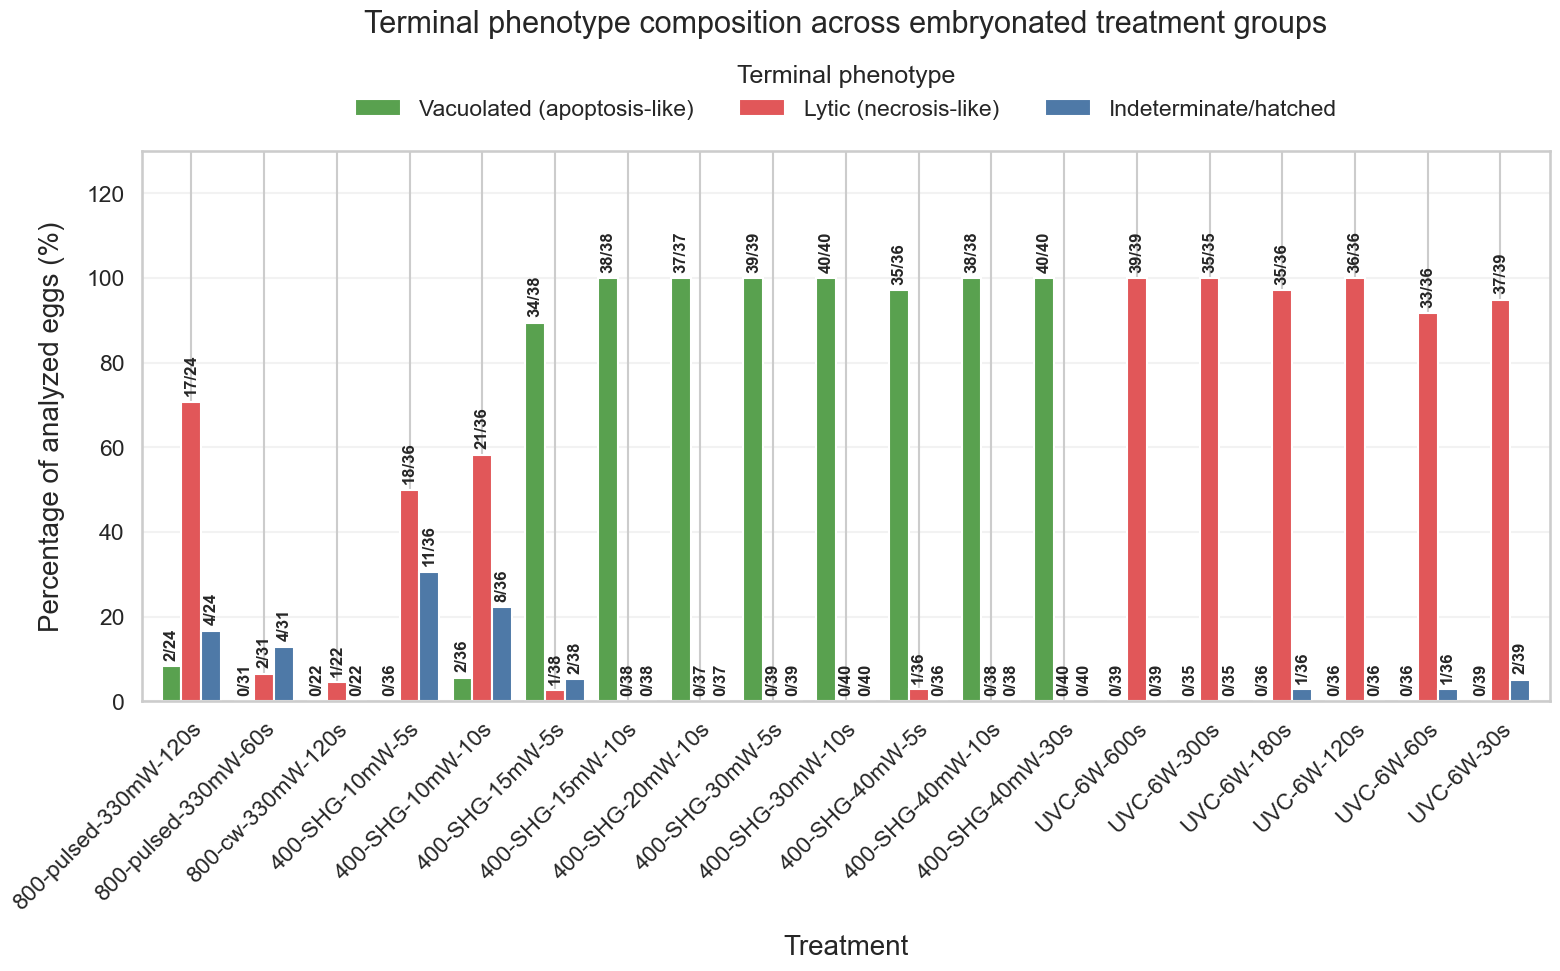

Saved: /Users/arkadi/Desktop/lia-sth/exp_data/data_analysis/cross-modality/embryonated/plots/sumup_embryonated_death_mode_distribution.png


In [21]:
# Terminal phenotype distribution (n, %) per treatment

print('Figure caption: Terminal phenotype composition across all embryonated treatment groups in the summary notebook. Bars show treatment-specific percentages among analyzed eggs (no_larvae excluded), colors encode Vacuolated (apoptosis-like), Lytic (necrosis-like), and Indeterminate/hatched outcomes, and bar labels report n/total analyzed counts for each treatment-phenotype pair.')

death_rows = []
for group in TREATMENT_GROUP_ORDER:
    sub = analysis_df.loc[(analysis_df["analysis_group"] == group) & (analysis_df["is_analyzed"])].copy()
    n_total = int(len(sub))
    for mode in DEATH_MODES:
        n_mode = int((sub["death_mode"] == mode).sum())
        death_rows.append(
            {
                "treatment": group,
                "modality": modality_from_group(group),
                "death_mode": mode,
                "n_total_analyzed": n_total,
                "n": n_mode,
                "pct": round(pct(n_mode, n_total), 1),
            }
        )

death_mode_dist_df = pd.DataFrame(death_rows)
death_mode_dist_df[TERMINAL_PHENOTYPE_LABEL] = (
    death_mode_dist_df["death_mode"].map(DEATH_MODE_DISPLAY).fillna(death_mode_dist_df["death_mode"])
)
display(death_mode_dist_df.drop(columns=["death_mode"]))

BAR_WIDTH = 1.2
GROUP_GAP = 0.8
n_modes = len(DEATH_MODE_DISPLAY_ORDER)
group_width = n_modes * BAR_WIDTH
group_spacing = group_width + GROUP_GAP
group_centers = np.arange(len(TREATMENT_GROUP_ORDER)) * group_spacing
mode_offsets = (np.arange(n_modes) - (n_modes - 1) / 2) * BAR_WIDTH

fig, ax = plt.subplots(figsize=(16, 12))

for i, mode_label in enumerate(DEATH_MODE_DISPLAY_ORDER):
    mode_rows = (
        death_mode_dist_df.loc[death_mode_dist_df[TERMINAL_PHENOTYPE_LABEL] == mode_label]
        .set_index("treatment")
        .reindex(TREATMENT_GROUP_ORDER)
    )

    heights = mode_rows["pct"].fillna(0).to_numpy(dtype=float)
    n_vals = mode_rows["n"].fillna(0).astype(int).to_numpy()
    n_total_vals = mode_rows["n_total_analyzed"].fillna(0).astype(int).to_numpy()

    xs = group_centers + mode_offsets[i]
    bars = ax.bar(
        xs,
        heights,
        width=BAR_WIDTH,
        color=DEATH_MODE_PALETTE[mode_label],
        label=mode_label,
    )

    labels = [f"{n_mode}/{n_total}" if n_total > 0 else "" for n_mode, n_total in zip(n_vals, n_total_vals)]
    bar_texts = ax.bar_label(bars, labels=labels, padding=4, fontsize=12, rotation=90, fontweight="bold")
    for txt in bar_texts:
        txt.set_clip_on(False)

ax.set_xlabel("Treatment", labelpad=15, fontsize=20)
ax.set_ylabel("Percentage of analyzed eggs (%)", fontsize=20, labelpad=15)
ax.set_title("Terminal phenotype composition across embryonated treatment groups", y=1.2, fontsize=22)
ymax = death_mode_dist_df["pct"].dropna().max() if len(death_mode_dist_df) else 100
ax.set_ylim(0, max(130, (float(ymax) + 10) if pd.notna(ymax) else 130))
ax.legend(title=TERMINAL_PHENOTYPE_LABEL, frameon=False, loc="lower center", bbox_to_anchor=(0.5, 1.02), ncol=3)
ax.grid(axis="y", alpha=0.25)

sumup_xlabels = TREATMENT_GROUP_ORDER
ax.set_xticks(group_centers)
ax.set_xticklabels(sumup_xlabels, rotation=45, ha="right", rotation_mode="anchor")

xpad = BAR_WIDTH
ax.set_xlim(group_centers[0] - group_width / 2 - xpad, group_centers[-1] + group_width / 2 + xpad)
plt.tight_layout(rect=[0, 0, 1, 0.9])
out_png = PLOTS_DIR / "sumup_embryonated_death_mode_distribution.png"
plt.savefig(out_png, dpi=600, bbox_inches="tight")
plt.show()

print(f"Saved: {out_png.resolve()}")
death_mode_dist_df.drop(columns=["death_mode"]).to_csv(TABLES_DIR / "sumup_embryonated_death_mode_distribution.csv", index=False)



Figure caption: Terminal twitching frequency for UVC treatment groups in the summary notebook. Bars report `n_terminal_twitching / n_total_excluding_no_larvae * 100` per UVC treatment; companion tables list both all-treatment counts and the UVC subset used for this dose-focused plot.


,treatment,modality,n_total_excluding_no_larvae,n_terminal_twitching,pct_terminal_twitching
0,800-pulsed-330mW-120s,800nm,24,0,0.0
1,800-pulsed-330mW-60s,800nm,31,0,0.0
2,800-cw-330mW-120s,800nm,22,0,0.0
3,400-SHG-10mW-5s,SHG,36,0,0.0
4,400-SHG-10mW-10s,SHG,36,0,0.0
5,400-SHG-15mW-5s,SHG,38,0,0.0
6,400-SHG-15mW-10s,SHG,38,0,0.0
7,400-SHG-20mW-10s,SHG,37,0,0.0
8,400-SHG-30mW-5s,SHG,39,0,0.0
9,400-SHG-30mW-10s,SHG,40,0,0.0


,treatment,modality,n_total_excluding_no_larvae,n_terminal_twitching,pct_terminal_twitching
13,UVC-6W-600s,UVC,39,2,5.1
14,UVC-6W-300s,UVC,35,35,100.0
15,UVC-6W-180s,UVC,36,34,94.4
16,UVC-6W-120s,UVC,36,0,0.0
17,UVC-6W-60s,UVC,36,0,0.0
18,UVC-6W-30s,UVC,39,0,0.0


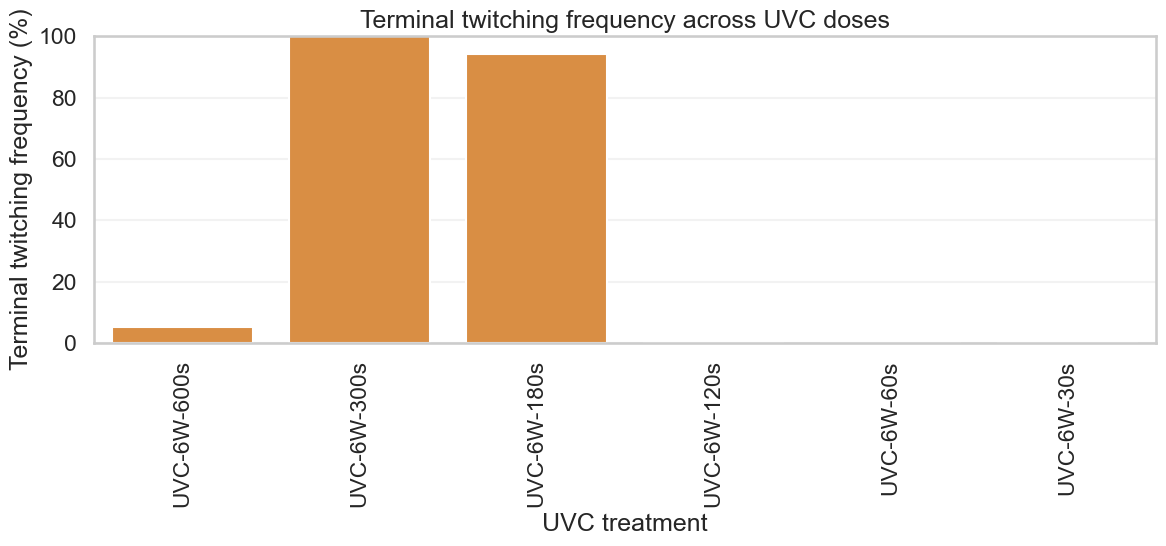

Saved: /Users/arkadi/Desktop/lia-sth/exp_data/data_analysis/cross-modality/embryonated/plots/sumup_embryonated_terminal_twitching_frequency_uvc.png


In [22]:
# Terminal twitching analysis (UVC-specific phenotype)

print('Figure caption: Terminal twitching frequency for UVC treatment groups in the summary notebook. Bars report `n_terminal_twitching / n_total_excluding_no_larvae * 100` per UVC treatment; companion tables list both all-treatment counts and the UVC subset used for this dose-focused plot.')

tt_rows = []
for group in TREATMENT_GROUP_ORDER:
    sub = analysis_df.loc[(analysis_df["analysis_group"] == group) & (analysis_df["is_analyzed"])].copy()
    n_total = int(len(sub))
    n_tt = int(sub["flag_terminal_twitching"].sum())
    tt_rows.append(
        {
            "treatment": group,
            "modality": modality_from_group(group),
            "n_total_excluding_no_larvae": n_total,
            "n_terminal_twitching": n_tt,
            "pct_terminal_twitching": round(pct(n_tt, n_total), 1),
        }
    )
terminal_twitching_all_df = pd.DataFrame(tt_rows)
display(terminal_twitching_all_df)

terminal_twitching_uvc_df = terminal_twitching_all_df[
    terminal_twitching_all_df["treatment"].isin(GROUPS_UVC)
].copy()
display(terminal_twitching_uvc_df)

fig, ax = plt.subplots(figsize=(12, 5.8))
sns.barplot(
    data=terminal_twitching_uvc_df,
    x="treatment",
    y="pct_terminal_twitching",
    order=GROUPS_UVC,
    color="#f28e2b",
    ax=ax,
)
ax.set_xlabel("UVC treatment")
ax.set_ylabel("Terminal twitching frequency (%)")
ax.set_title("Terminal twitching frequency across UVC doses")
ax.set_ylim(0, 100)
ax.grid(axis="y", alpha=0.25)
ax.tick_params(axis="x", labelrotation=90)
plt.tight_layout()

out_png = PLOTS_DIR / "sumup_embryonated_terminal_twitching_frequency_uvc.png"
plt.savefig(out_png, dpi=600, bbox_inches="tight")
plt.show()

terminal_twitching_all_df.to_csv(TABLES_DIR / "sumup_embryonated_terminal_twitching_all_treatments.csv", index=False)
terminal_twitching_uvc_df.to_csv(TABLES_DIR / "sumup_embryonated_terminal_twitching_uvc.csv", index=False)
print(f"Saved: {out_png.resolve()}")



In [23]:
# Death-after-hatch events per treatment

dah_rows = []
for group in TREATMENT_GROUP_ORDER:
    sub = analysis_df.loc[(analysis_df["analysis_group"] == group) & (analysis_df["is_analyzed"])].copy()
    n_total = int(len(sub))
    n_dah = int(sub["flag_death_after_hatch"].sum())
    dah_rows.append(
        {
            "treatment": group,
            "modality": modality_from_group(group),
            "n_total_excluding_no_larvae": n_total,
            "n_death_after_hatch": n_dah,
            "pct_death_after_hatch": round(pct(n_dah, n_total), 1),
        }
    )

death_after_hatch_df = pd.DataFrame(dah_rows)
display(death_after_hatch_df)

death_after_hatch_df.to_csv(TABLES_DIR / "sumup_embryonated_death_after_hatch_summary.csv", index=False)


,treatment,modality,n_total_excluding_no_larvae,n_death_after_hatch,pct_death_after_hatch
0,800-pulsed-330mW-120s,800nm,24,4,16.7
1,800-pulsed-330mW-60s,800nm,31,0,0.0
2,800-cw-330mW-120s,800nm,22,0,0.0
3,400-SHG-10mW-5s,SHG,36,11,30.6
4,400-SHG-10mW-10s,SHG,36,8,22.2
5,400-SHG-15mW-5s,SHG,38,1,2.6
6,400-SHG-15mW-10s,SHG,38,0,0.0
7,400-SHG-20mW-10s,SHG,37,0,0.0
8,400-SHG-30mW-5s,SHG,39,0,0.0
9,400-SHG-30mW-10s,SHG,40,0,0.0


Figure caption: Summary distribution of in-egg motion-stop timing (`dt_motion_stop_h`) across treatment groups retained under harmonized inclusion rules. Only in-egg stop events are plotted; groups are filtered by modality-specific inclusion logic, manual exclusions, and minimum sample size thresholds. Boxes show median/IQR with 1.5xIQR whiskers (fliers hidden), with jittered points for individual eggs.


,analysis_group,n_points
0,800-pulsed-330mW-120s,19
1,800-pulsed-330mW-60s,6
2,800-cw-330mW-120s,1
3,400-SHG-10mW-5s,18
4,400-SHG-10mW-10s,23
5,400-SHG-15mW-5s,36
6,400-SHG-15mW-10s,38
7,400-SHG-20mW-10s,37
8,400-SHG-30mW-5s,39
9,400-SHG-30mW-10s,40


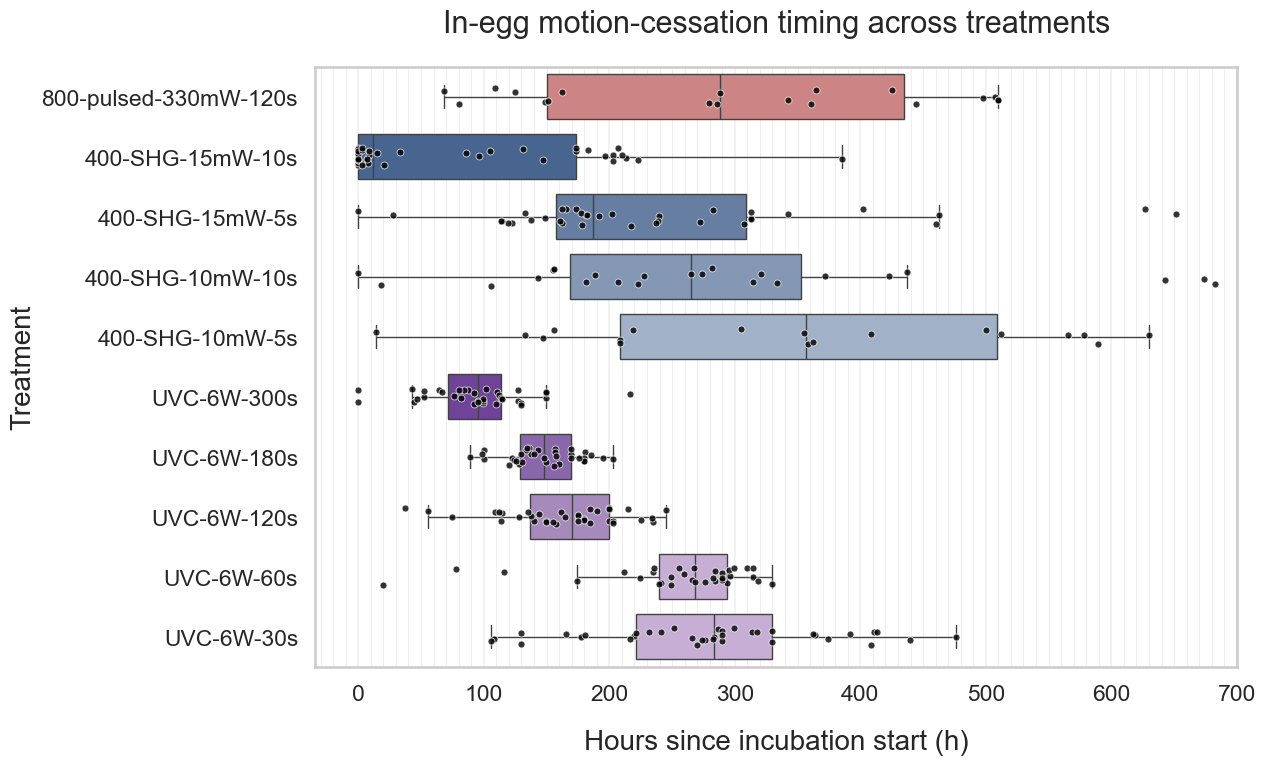

Saved: /Users/arkadi/Desktop/lia-sth/exp_data/data_analysis/cross-modality/embryonated/plots/sumup_embryonated_dt_motion_stop_boxplot.png


,group,n_total_excluding_no_larvae,n_points_in_boxplot,median_dt_motion_stop_h,q1_dt_motion_stop_h,q3_dt_motion_stop_h,iqr_dt_motion_stop_h,iqr_range_dt_motion_stop_h,mean_dt_motion_stop_h,sd_dt_motion_stop_h,n_still_moving,pct_still_moving_survived
0,800-pulsed-330mW-120s,24,19,288.0,150.00,434.50,284.50,150.00 to 434.50,297.89,158.15,1,4.2
1,400-SHG-15mW-10s,38,38,11.7,0.00,173.20,173.20,0.00 to 173.20,80.38,99.81,0,0.0
2,400-SHG-15mW-5s,38,36,187.0,157.50,308.75,151.25,157.50 to 308.75,237.04,143.12,1,2.6
3,400-SHG-10mW-10s,36,23,264.8,168.80,352.80,184.00,168.80 to 352.80,288.07,186.31,5,13.9
4,400-SHG-10mW-5s,36,18,356.7,208.20,509.20,301.00,208.20 to 509.20,347.26,185.39,7,19.4
5,UVC-6W-300s,35,35,95.5,71.50,114.00,42.50,71.50 to 114.00,94.16,42.60,0,0.0
6,UVC-6W-180s,36,35,147.8,128.80,169.80,41.00,128.80 to 169.80,147.60,28.81,0,0.0
7,UVC-6W-120s,36,36,169.9,137.15,199.90,62.75,137.15 to 199.90,162.34,48.62,0,0.0
8,UVC-6W-60s,36,33,268.5,239.50,293.50,54.00,239.50 to 293.50,253.29,68.49,2,5.6
9,UVC-6W-30s,39,37,283.5,221.50,329.50,108.00,221.50 to 329.50,281.47,93.31,0,0.0


Saved: /Users/arkadi/Desktop/lia-sth/exp_data/data_analysis/cross-modality/embryonated/tables/sumup_embryonated_dt_motion_stop_boxplot_summary_stats.csv
Note: Excluded from summary boxplot to match individual notebook boxplot inclusions:
 - 400-SHG-20mW-10s
 - 400-SHG-30mW-5s
 - 400-SHG-30mW-10s
 - 400-SHG-40mW-5s
 - 400-SHG-40mW-10s
 - 400-SHG-40mW-30s
 - UVC-6W-600s
Note: Additional manual exclusion in this summary boxplot:
 - 800-pulsed-330mW-60s: excluded due to low in-egg stop sample size (n=6) and high survival/continued motion (25/31, 80.6%).
Note: Additional groups excluded due to n<2 in-egg stop observations:
 - 800-cw-330mW-120s


In [24]:
# Horizontal boxplot + stripplot overlay: in-egg motion stop times (summary groups)

print('Figure caption: Summary distribution of in-egg motion-stop timing (`dt_motion_stop_h`) across treatment groups retained under harmonized inclusion rules. Only in-egg stop events are plotted; groups are filtered by modality-specific inclusion logic, manual exclusions, and minimum sample size thresholds. Boxes show median/IQR with 1.5xIQR whiskers (fliers hidden), with jittered points for individual eggs.')

MANUAL_EXCLUDE_FROM_PLOT = {"800-pulsed-330mW-60s"}

boxplot_df = analysis_df.loc[
    analysis_df["analysis_group"].isin(TREATMENT_GROUP_ORDER)
    & analysis_df["is_stopped_in_egg"]
    & analysis_df["dt_motion_stop_h"].notna(),
    ["egg_uid", "analysis_group", "dt_motion_stop_h", "flags", "death_mode"],
].copy()

point_counts = (
    boxplot_df.groupby("analysis_group", observed=False)
    .size()
    .reindex(TREATMENT_GROUP_ORDER, fill_value=0)
    .rename("n_points")
    .reset_index()
)
display(point_counts)

MIN_N_FOR_BOX = 2
groups_for_plot = [
    g for g in BOX_CANDIDATE_GROUPS
    if g not in MANUAL_EXCLUDE_FROM_PLOT
    and int(point_counts.loc[point_counts["analysis_group"] == g, "n_points"].sum()) >= MIN_N_FOR_BOX
]

if not groups_for_plot:
    raise ValueError("No treatment remains for summary boxplot after inclusion/exclusion rules.")

desired_shg_order = [
    "400-SHG-15mW-10s",
    "400-SHG-15mW-5s",
    "400-SHG-10mW-10s",
    "400-SHG-10mW-5s",
]
non_shg_non_uvc = [
    g for g in groups_for_plot
    if (not g.startswith("400-SHG-")) and (not g.startswith("UVC-"))
]
ordered_shg = [g for g in desired_shg_order if g in groups_for_plot]
remaining_shg = [
    g for g in groups_for_plot
    if g.startswith("400-SHG-") and g not in ordered_shg
]
uvc_groups_in_original_order = [g for g in groups_for_plot if g.startswith("UVC-")]

groups_for_plot = [
    *non_shg_non_uvc,
    *ordered_shg,
    *remaining_shg,
    *uvc_groups_in_original_order,
]

plot_df = boxplot_df[boxplot_df["analysis_group"].isin(groups_for_plot)].copy()

palette = {}

palette_800 = {
    "800-pulsed-330mW-120s": "#d97878",
    "800-pulsed-330mW-60s": "#e99f9f",
    "800-cw-330mW-120s": "#e99f9f",
}
palette.update({g: c for g, c in palette_800.items() if g in groups_for_plot})

shg_groups_for_plot = [g for g in groups_for_plot if g.startswith("400-SHG-")]
if shg_groups_for_plot:
    shg_palette_vals = sns.blend_palette(["#3c639c", "#9bb0cd"], n_colors=max(len(shg_groups_for_plot), 3))
    palette.update({g: shg_palette_vals[i] for i, g in enumerate(shg_groups_for_plot)})

uvc_treatment_colors = {
    "UVC-6W-600s": "#4B1D7F",
    "UVC-6W-300s": "#6E35A6",
    "UVC-6W-180s": "#8B5CB5",
    "UVC-6W-120s": "#A882C4",
    "UVC-6W-60s": "#C9A8DB",
    "UVC-6W-30s": "#C9A8DB",
}
palette.update({g: uvc_treatment_colors[g] for g in groups_for_plot if g in uvc_treatment_colors})

palette = {g: palette.get(g, "#999999") for g in groups_for_plot}

fig, ax = plt.subplots(figsize=(13, 8))
sns.boxplot(
    data=plot_df,
    x="dt_motion_stop_h",
    y="analysis_group",
    hue="analysis_group",
    order=groups_for_plot,
    hue_order=groups_for_plot,
    palette=palette,
    showfliers=False,
    linewidth=1.0,
    width=0.75,
    dodge=False,
    legend=False,
    ax=ax,
)

sns.stripplot(
    data=plot_df,
    x="dt_motion_stop_h",
    y="analysis_group",
    order=groups_for_plot,
    color="black",
    jitter=0.15,
    size=5,
    alpha=0.8,
    linewidth=0.6,
    edgecolor="white",
    ax=ax,
)

ax.set_xlabel("Hours since incubation start (h)", labelpad=18, fontsize=20)
ax.set_ylabel("Treatment", fontsize=20)
ax.set_title("In-egg motion-cessation timing across treatments", fontsize=22, pad=25)
left_pad_h = max(10.0, 0.05 * float(plot_df["dt_motion_stop_h"].max())) if len(plot_df) > 0 else 10.0
ax.set_xlim(-left_pad_h, MAX_FOOTAGE_H)
ax.grid(axis="x", alpha=0.25)
ax.xaxis.set_minor_locator(MultipleLocator(10))
ax.grid(axis="x", which="minor", color="#e0e0e0", linewidth=0.4, alpha=0.9)

plt.tight_layout()
out_png = PLOTS_DIR / "sumup_embryonated_dt_motion_stop_boxplot.png"
plt.savefig(out_png, dpi=600, bbox_inches="tight")
plt.show()

plot_df.to_csv(TABLES_DIR / "sumup_embryonated_dt_motion_stop_boxplot_data.csv", index=False)
point_counts.to_csv(TABLES_DIR / "sumup_embryonated_dt_motion_stop_boxplot_counts.csv", index=False)
print(f"Saved: {out_png.resolve()}")

summary_rows = []
for g in groups_for_plot:
    sub_times = plot_df.loc[plot_df["analysis_group"] == g, "dt_motion_stop_h"].dropna().astype(float)
    n_points = int(len(sub_times))

    med = float(sub_times.median()) if n_points > 0 else np.nan
    q1 = float(sub_times.quantile(0.25)) if n_points > 0 else np.nan
    q3 = float(sub_times.quantile(0.75)) if n_points > 0 else np.nan
    mean_v = float(sub_times.mean()) if n_points > 0 else np.nan
    sd_v = float(sub_times.std(ddof=1)) if n_points > 1 else np.nan

    sub_all = analysis_df.loc[(analysis_df["analysis_group"] == g) & (analysis_df["is_analyzed"])].copy()
    n_total = int(len(sub_all))
    n_still = int(sub_all["is_continued_motion"].sum())

    summary_rows.append(
        {
            "group": g,
            "n_total_excluding_no_larvae": n_total,
            "n_points_in_boxplot": n_points,
            "median_dt_motion_stop_h": round(med, 2) if pd.notna(med) else np.nan,
            "q1_dt_motion_stop_h": round(q1, 2) if pd.notna(q1) else np.nan,
            "q3_dt_motion_stop_h": round(q3, 2) if pd.notna(q3) else np.nan,
            "iqr_dt_motion_stop_h": (
                round(q3 - q1, 2) if pd.notna(q1) and pd.notna(q3) else np.nan
            ),
            "iqr_range_dt_motion_stop_h": (
                f"{q1:.2f} to {q3:.2f}" if pd.notna(q1) and pd.notna(q3) else np.nan
            ),
            "mean_dt_motion_stop_h": round(mean_v, 2) if pd.notna(mean_v) else np.nan,
            "sd_dt_motion_stop_h": round(sd_v, 2) if pd.notna(sd_v) else np.nan,
            "n_still_moving": n_still,
            "pct_still_moving_survived": round(pct(n_still, n_total), 1),
        }
    )

boxplot_summary_df = pd.DataFrame(summary_rows)
boxplot_summary_df["group"] = pd.Categorical(boxplot_summary_df["group"], categories=groups_for_plot, ordered=True)
boxplot_summary_df = boxplot_summary_df.sort_values("group").reset_index(drop=True)
display(boxplot_summary_df)

boxplot_summary_out = TABLES_DIR / "sumup_embryonated_dt_motion_stop_boxplot_summary_stats.csv"
boxplot_summary_df.to_csv(boxplot_summary_out, index=False)
print(f"Saved: {boxplot_summary_out.resolve()}")

excluded_predefined = [g for g in TREATMENT_GROUP_ORDER if g not in BOX_CANDIDATE_GROUPS]
if excluded_predefined:
    print("Note: Excluded from summary boxplot to match individual notebook boxplot inclusions:")
    print(" - " + "\n - ".join(excluded_predefined))

excluded_manual = [g for g in BOX_CANDIDATE_GROUPS if g in MANUAL_EXCLUDE_FROM_PLOT]
if excluded_manual:
    print("Note: Additional manual exclusion in this summary boxplot:")
    for g in excluded_manual:
        n_in_egg = int(point_counts.loc[point_counts["analysis_group"] == g, "n_points"].sum())
        sub = analysis_df.loc[(analysis_df["analysis_group"] == g) & (analysis_df["is_analyzed"])].copy()
        n_total = int(len(sub))
        n_cont = int(sub["is_continued_motion"].sum())
        pct_cont = round(pct(n_cont, n_total), 1)
        print(
            f" - {g}: excluded due to low in-egg stop sample size (n={n_in_egg}) "
            f"and high survival/continued motion ({n_cont}/{n_total}, {pct_cont}%)."
        )

excluded_low_n = [
    g for g in BOX_CANDIDATE_GROUPS
    if g not in MANUAL_EXCLUDE_FROM_PLOT
    and int(point_counts.loc[point_counts["analysis_group"] == g, "n_points"].sum()) < MIN_N_FOR_BOX
]
if excluded_low_n:
    print(f"Note: Additional groups excluded due to n<{MIN_N_FOR_BOX} in-egg stop observations:")
    print(" - " + "\n - ".join(excluded_low_n))




<!-- Cell purpose: Introduce figure caption:. -->

Figure caption:
Summary boxplot of in-egg motion-stop timing (`dt_motion_stop_h`) across included treatment groups from 800nm, SHG, and UVC analyses. Each point is one egg with an observed in-egg stop event; `death_after_hatch` rows are excluded. Boxes show median and IQR with 1.5xIQR whiskers (fliers hidden), with jittered points for all included eggs. Group inclusion follows harmonized modality-specific rules (including manual and low-n exclusions) to maintain consistency with individual notebook plots.


Figure caption: Faceted Kaplan-Meier curves of continued larval motion in embryonated eggs, split by modality (800 nm plus pooled control, SHG, UVC) to reduce overplotting. Event is observed in-window motion stop (`event_observed=1`), censoring indicates continued motion/no in-window stop (`event_observed=0`), and censor marks are displayed. Group inclusion mirrors modality-specific KM rules used throughout the summary analysis.


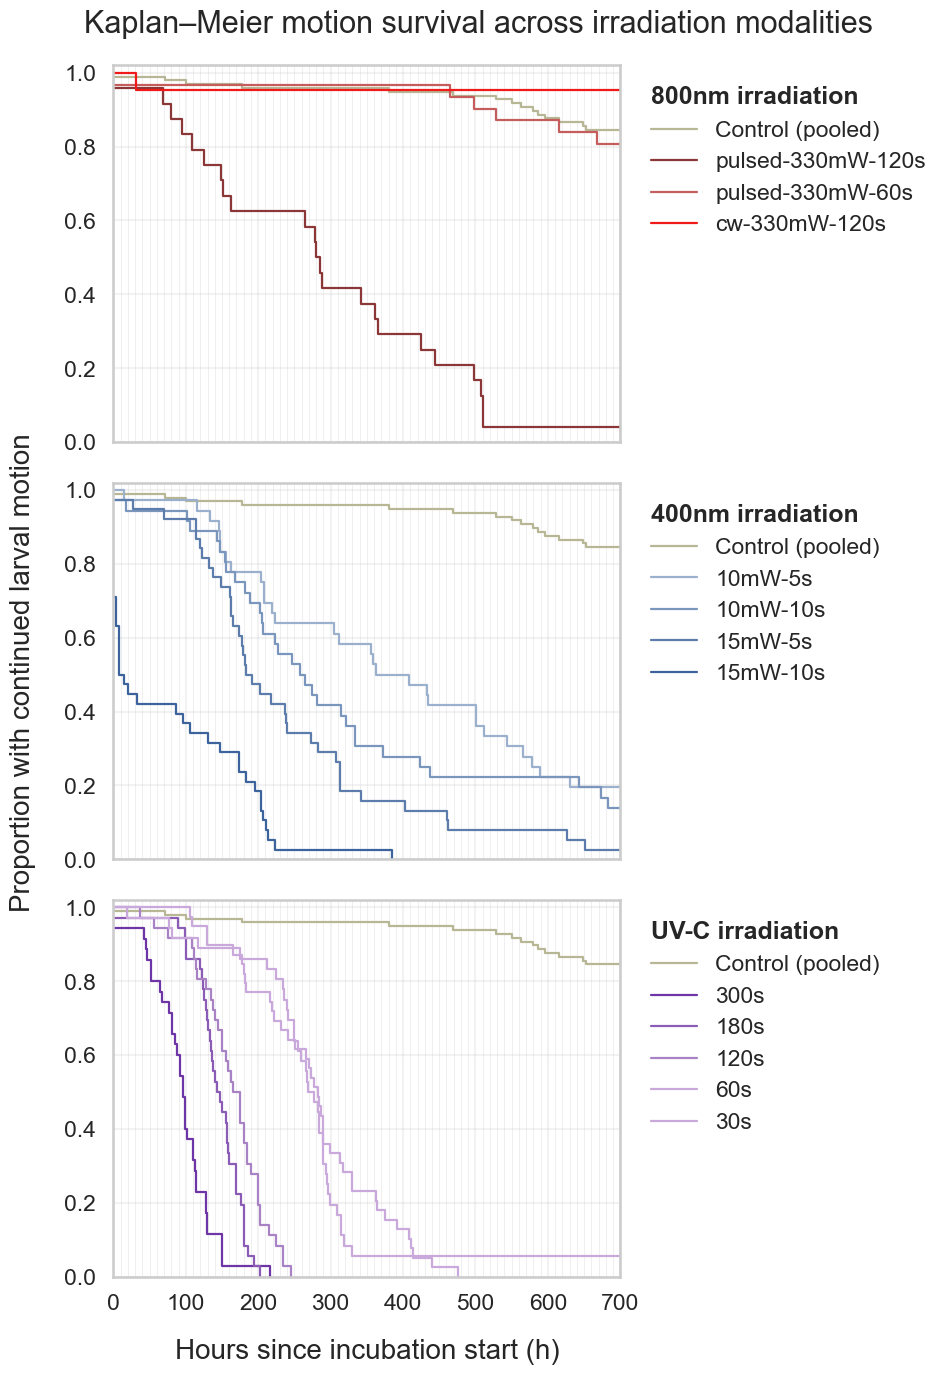

,group,modality,n_total,n_events,n_censored,median_survival_h
0,Control (pooled),Control,97,15,82,inf
1,800-pulsed-330mW-120s,800nm,24,23,1,279.6
2,800-pulsed-330mW-60s,800nm,31,6,25,inf
3,800-cw-330mW-120s,800nm,22,1,21,inf
4,400-SHG-10mW-5s,SHG,36,29,7,362.2
5,400-SHG-10mW-10s,SHG,36,31,5,257.8
6,400-SHG-15mW-5s,SHG,38,37,1,182.5
7,400-SHG-15mW-10s,SHG,38,38,0,8.2
8,UVC-6W-300s,UVC,35,35,0,95.5
9,UVC-6W-180s,UVC,36,36,0,142.8


Saved: /Users/arkadi/Desktop/lia-sth/exp_data/data_analysis/cross-modality/embryonated/plots/sumup_embryonated_kaplan_meier_motion_survival.png
Note: Excluded from summary KM plot to match individual notebook KM inclusions:
 - 400-SHG-20mW-10s
 - 400-SHG-30mW-5s
 - 400-SHG-30mW-10s
 - 400-SHG-40mW-5s
 - 400-SHG-40mW-10s
 - 400-SHG-40mW-30s
 - UVC-6W-600s


In [25]:
# Kaplan-Meier survival curve (continued larval motion)

print('Figure caption: Faceted Kaplan-Meier curves of continued larval motion in embryonated eggs, split by modality (800 nm plus pooled control, SHG, UVC) to reduce overplotting. Event is observed in-window motion stop (`event_observed=1`), censoring indicates continued motion/no in-window stop (`event_observed=0`), and censor marks are displayed. Group inclusion mirrors modality-specific KM rules used throughout the summary analysis.')

if KaplanMeierFitter is None or logrank_test is None or multivariate_logrank_test is None:
    raise ImportError("lifelines is required for Kaplan-Meier and log-rank analyses. Install with: pip install lifelines")

survival_df = analysis_df.loc[
    analysis_df["analysis_group"].isin(ALL_GROUP_ORDER) & analysis_df["is_analyzed"],
    [
        "egg_uid",
        "analysis_group",
        "duration_survival_h",
        "is_event_survival",
        "dt_motion_stop_h",
        "t_motion_stop_h",
        "death_mode",
        "flags",
    ],
].copy()

survival_df = survival_df.rename(
    columns={
        "duration_survival_h": "duration_h",
        "is_event_survival": "event_observed",
    }
)
survival_df["event_observed"] = survival_df["event_observed"].astype(int)
survival_df["duration_h"] = survival_df["duration_h"].fillna(MAX_FOOTAGE_H).astype(float).clip(lower=0, upper=MAX_FOOTAGE_H)

groups_for_km_plot = [
    g for g in KM_CANDIDATE_GROUPS
    if int(survival_df.loc[survival_df["analysis_group"] == g].shape[0]) > 0
]

km_colors = {
    "Control (pooled)": "#b7b695",
    "800-pulsed-330mW-120s": "#8b3637",
    "800-pulsed-330mW-60s": "#c55d5d",
    "800-cw-330mW-120s": "#f11a1a",
}

shg_groups_for_km = [g for g in groups_for_km_plot if g.startswith("400-SHG-")]
if shg_groups_for_km:
    shg_palette_vals = sns.blend_palette(["#9bb0cd", "#3c639c"], n_colors=max(len(shg_groups_for_km), 3))
    km_colors.update({g: shg_palette_vals[i] for i, g in enumerate(shg_groups_for_km)})

uvc_treatment_colors = {
    "UVC-6W-600s": "#4B1D7F",
    "UVC-6W-300s": "#6E35A6",
    "UVC-6W-180s": "#8B5CB5",
    "UVC-6W-120s": "#A882C4",
    "UVC-6W-60s": "#C9A8DB",
    "UVC-6W-30s": "#C9A8DB",
}
km_colors.update({g: uvc_treatment_colors[g] for g in groups_for_km_plot if g in uvc_treatment_colors})

km_colors = {g: km_colors.get(g, "#999999") for g in groups_for_km_plot}
km_rows = []
km_fit_by_group = {}
for group in groups_for_km_plot:
    g = survival_df.loc[survival_df["analysis_group"] == group].copy()
    if g.empty:
        continue

    kmf = KaplanMeierFitter()
    kmf.fit(
        durations=g["duration_h"],
        event_observed=g["event_observed"],
        label=group,
    )
    km_fit_by_group[group] = kmf

    med = kmf.median_survival_time_
    km_rows.append(
        {
            "group": group,
            "modality": modality_from_group(group),
            "n_total": int(len(g)),
            "n_events": int(g["event_observed"].sum()),
            "n_censored": int((g["event_observed"] == 0).sum()),
            "median_survival_h": float(med) if np.isfinite(med) else np.inf,
        }
    )

km_facet_specs = [
    {
        "legend_title": "800nm irradiation",
        "groups": ["Control (pooled)", *GROUPS_800],
    },
    {
        "legend_title": "400nm irradiation",
        "groups": ["Control (pooled)", *list(SHG_INCLUDED)],
    },
    {
        "legend_title": "UV-C irradiation",
        "groups": ["Control (pooled)", *list(UVC_PLOT_KM_INCLUDED)],
    },
]


def format_group_label_for_legend(group_label: str, legend_title: str) -> str:
    if group_label == "Control (pooled)":
        return group_label
    if legend_title == "800nm irradiation":
        return group_label.replace("800-", "")
    if legend_title == "400nm irradiation":
        return group_label.replace("400-SHG-", "")
    if legend_title == "UV-C irradiation":
        return group_label.replace("UVC-6W-", "")
    return group_label

fig, axes = plt.subplots(len(km_facet_specs), 1, figsize=(13, 4.8 * len(km_facet_specs)), sharex=True, sharey=True)
if len(km_facet_specs) == 1:
    axes = [axes]

for ax, spec in zip(axes, km_facet_specs):
    facet_groups = [g for g in spec["groups"] if g in groups_for_km_plot]

    if not facet_groups:
        ax.text(0.5, 0.5, f"No data for {spec['legend_title']}", ha="center", va="center", transform=ax.transAxes)
        ax.set_xlim(0, MAX_FOOTAGE_H)
        ax.set_ylim(0, 1.02)
        ax.grid(alpha=0.25)
        ax.xaxis.set_minor_locator(MultipleLocator(10))
        ax.grid(axis="x", which="minor", color="#e0e0e0", linewidth=0.4, alpha=0.9)
        continue

    for group in facet_groups:
        km_fit_by_group[group].plot_survival_function(
            ax=ax,
            ci_show=False,
            color=km_colors.get(group, None),
            show_censors=True,
            censor_styles={"ms": 4, "marker": "|", "mew": 1.0},
            linewidth=1.6,
        )

    ax.set_xlim(0, MAX_FOOTAGE_H)
    ax.set_ylim(0, 1.02)
    ax.grid(alpha=0.25)
    ax.xaxis.set_minor_locator(MultipleLocator(10))
    ax.grid(axis="x", which="minor", color="#e0e0e0", linewidth=0.4, alpha=0.9)
    handles, labels = ax.get_legend_handles_labels()
    formatted_labels = [format_group_label_for_legend(lbl, spec["legend_title"]) for lbl in labels]
    legend = ax.legend(
        handles,
        formatted_labels,
        title=spec["legend_title"],
        frameon=False,
        loc="upper left",
        bbox_to_anchor=(1.02, 1),
    )
    legend.get_title().set_ha("left")
    legend.get_title().set_fontweight("bold")
    if hasattr(legend, "_legend_box"):
        legend._legend_box.align = "left"

axes[-1].set_xlabel("Hours since incubation start (h)", labelpad=18, fontsize=20)
for ax in axes[:-1]:
    ax.set_xlabel("")

fig.supylabel("Proportion with continued larval motion", x=0.08, fontsize=20)
TITLE_RECT_LEFT = 0.06
TITLE_RECT_RIGHT = 0.82
TITLE_RECT_CENTER = (TITLE_RECT_LEFT + TITLE_RECT_RIGHT) / 2
fig.suptitle("Kaplan–Meier motion survival across irradiation modalities", x=TITLE_RECT_CENTER, y=0.96, ha="center", fontsize=22)
plt.tight_layout(rect=[TITLE_RECT_LEFT, 0, TITLE_RECT_RIGHT, 0.98])

out_png = PLOTS_DIR / "sumup_embryonated_kaplan_meier_motion_survival.png"
plt.savefig(out_png, dpi=600, bbox_inches="tight")
plt.show()

km_summary_df = pd.DataFrame(km_rows)
display(km_summary_df)

km_summary_df.to_csv(TABLES_DIR / "sumup_embryonated_km_summary.csv", index=False)
survival_df.to_csv(TABLES_DIR / "sumup_embryonated_km_input_data.csv", index=False)
print(f"Saved: {out_png.resolve()}")


excluded_km = [g for g in TREATMENT_GROUP_ORDER if g not in KM_CANDIDATE_GROUPS]
if excluded_km:
    print("Note: Excluded from summary KM plot to match individual notebook KM inclusions:")
    print(" - " + "\n - ".join(excluded_km))




<!-- Cell purpose: Introduce figure caption:. -->

Figure caption:
Faceted Kaplan-Meier curves of continued larval motion in embryonated eggs, displayed as three modality panels (800nm + pooled control, SHG, UVC) to reduce overplotting. Event definition: observed in-window motion stop (`event_observed = 1`). Censoring definition: continued motion/no in-window stop (`event_observed = 0`), shown as tick marks. Included groups follow the same modality-specific KM inclusion rules as individual notebooks; pooled control appears in the 800nm facet as the shared reference trajectory.


Figure caption: Summary normality diagnostics for `dt_motion_stop_h` across included treated groups (control excluded from inferential stats). Shapiro-Wilk statistics are reported where n>=3, and Q-Q panels compare observed to theoretical normal quantiles by group. Low-n or empty groups are explicitly marked, supporting selection of parametric versus non-parametric test families.
Included treated groups for stats (13): 800-pulsed-330mW-120s, 800-pulsed-330mW-60s, 800-cw-330mW-120s, 400-SHG-10mW-5s, 400-SHG-10mW-10s, 400-SHG-15mW-5s, 400-SHG-15mW-10s, UVC-6W-600s, UVC-6W-300s, UVC-6W-180s, UVC-6W-120s, UVC-6W-60s, UVC-6W-30s
Note: Excluded from summary inferential stats to match individual notebook stats inclusions:
 - 400-SHG-20mW-10s
 - 400-SHG-30mW-5s
 - 400-SHG-30mW-10s
 - 400-SHG-40mW-5s
 - 400-SHG-40mW-10s
 - 400-SHG-40mW-30s


,group,modality,n_stopped_in_egg,shapiro_W,shapiro_p,normal_by_shapiro_p_gt_0_05,note
0,800-pulsed-330mW-120s,800nm,19,0.906484,6.382794e-02,True,
1,800-pulsed-330mW-60s,800nm,6,0.788210,4.591699e-02,False,
2,800-cw-330mW-120s,800nm,1,NaN,NaN,NaN,Shapiro requires n>=3
3,400-SHG-10mW-5s,SHG,18,0.947606,3.887138e-01,True,
4,400-SHG-10mW-10s,SHG,23,0.919313,6.440285e-02,True,
5,400-SHG-15mW-5s,SHG,36,0.887817,1.611185e-03,False,
6,400-SHG-15mW-10s,SHG,38,0.777402,3.740051e-06,False,
7,UVC-6W-600s,UVC,39,0.235922,5.400801e-13,False,
8,UVC-6W-300s,UVC,35,0.963962,2.996098e-01,True,
9,UVC-6W-180s,UVC,35,0.975879,6.226783e-01,True,


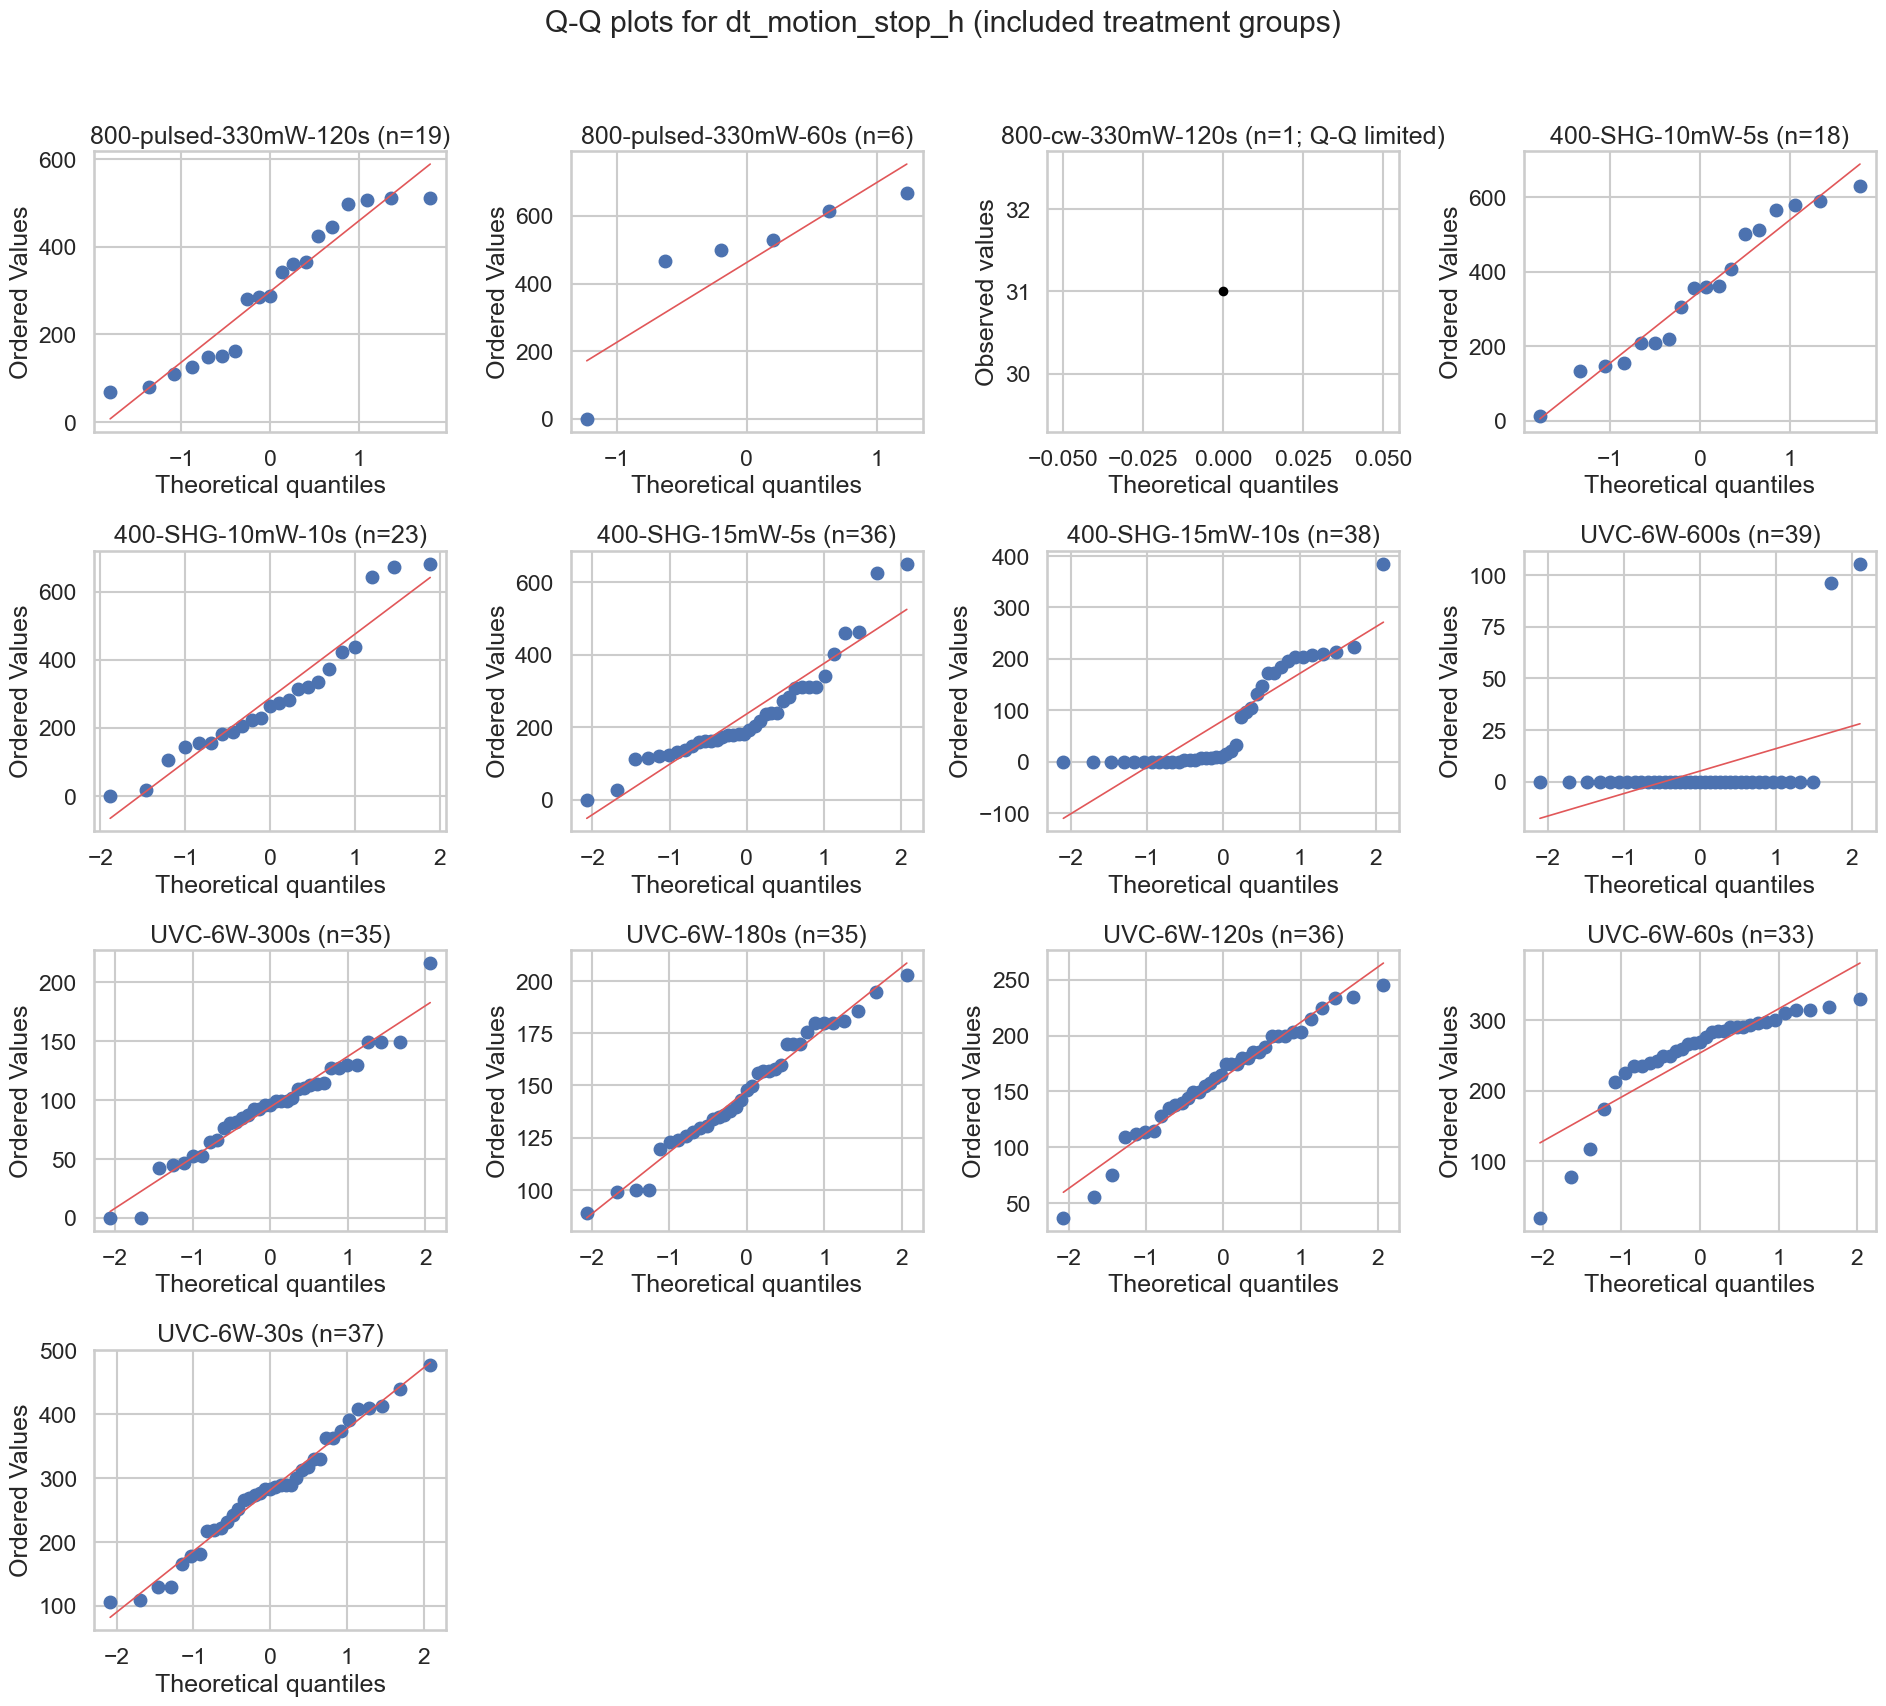

Saved: /Users/arkadi/Desktop/lia-sth/exp_data/data_analysis/cross-modality/embryonated/plots/sumup_embryonated_normality_qqplots.png
Selected comparison family: non_parametric
Reason: at least one included group had n<3 and/or failed Shapiro p<=0.05.


In [26]:
# Normality testing (Shapiro-Wilk) + Q-Q plots

print('Figure caption: Summary normality diagnostics for `dt_motion_stop_h` across included treated groups (control excluded from inferential stats). Shapiro-Wilk statistics are reported where n>=3, and Q-Q panels compare observed to theoretical normal quantiles by group. Low-n or empty groups are explicitly marked, supporting selection of parametric versus non-parametric test families.')

STATS_GROUP_ORDER = [
    g for g in STATS_TREATED_CANDIDATES
    if int(analysis_df.loc[(analysis_df["analysis_group"] == g) & (analysis_df["is_analyzed"])].shape[0]) > 0
]

print(f"Included treated groups for stats ({len(STATS_GROUP_ORDER)}): {', '.join(STATS_GROUP_ORDER)}")

excluded_from_stats = [g for g in TREATMENT_GROUP_ORDER if g not in STATS_TREATED_CANDIDATES]
if excluded_from_stats:
    print("Note: Excluded from summary inferential stats to match individual notebook stats inclusions:")
    print(" - " + "\n - ".join(excluded_from_stats))

time_comp_df = analysis_df.loc[
    analysis_df["analysis_group"].isin(STATS_GROUP_ORDER)
    & analysis_df["is_stopped_in_egg"]
    & analysis_df["dt_motion_stop_h"].notna(),
    ["analysis_group", "dt_motion_stop_h"],
].copy()

time_groups = {
    g: time_comp_df.loc[time_comp_df["analysis_group"] == g, "dt_motion_stop_h"].dropna().astype(float)
    for g in STATS_GROUP_ORDER
}

normality_rows = []
for group in STATS_GROUP_ORDER:
    vals = time_groups[group]
    n = int(len(vals))
    if n >= 3:
        sh_w, sh_p = stats.shapiro(vals)
    else:
        sh_w, sh_p = np.nan, np.nan

    normality_rows.append(
        {
            "group": group,
            "modality": modality_from_group(group),
            "n_stopped_in_egg": n,
            "shapiro_W": float(sh_w) if pd.notna(sh_w) else np.nan,
            "shapiro_p": float(sh_p) if pd.notna(sh_p) else np.nan,
            "normal_by_shapiro_p_gt_0_05": bool(sh_p > 0.05) if pd.notna(sh_p) else np.nan,
            "note": "Shapiro requires n>=3" if n < 3 else "",
        }
    )

normality_df = pd.DataFrame(normality_rows)
display(normality_df)
normality_df.to_csv(TABLES_DIR / "sumup_embryonated_normality_shapiro.csv", index=False)

n_groups = len(STATS_GROUP_ORDER)
ncols = 4
nrows = int(np.ceil(n_groups / ncols)) if n_groups > 0 else 1
fig, axes = plt.subplots(nrows, ncols, figsize=(4.8 * ncols, 4.2 * nrows))
axes = np.atleast_1d(axes).ravel()

for ax, group in zip(axes, STATS_GROUP_ORDER):
    vals = time_groups[group]
    n = len(vals)
    if n >= 2:
        stats.probplot(vals, dist="norm", plot=ax)
        ax.get_lines()[1].set_color("#e15759")
        ax.get_lines()[1].set_linewidth(1.2)
        ax.set_title(f"{group} (n={n})")
    elif n == 1:
        ax.scatter([0], vals.values, color="black", s=30)
        ax.set_title(f"{group} (n=1; Q-Q limited)")
        ax.set_xlabel("Theoretical quantiles")
        ax.set_ylabel("Observed values")
    else:
        ax.text(0.5, 0.5, "No in-egg stop data", ha="center", va="center", transform=ax.transAxes)
        ax.set_title(f"{group} (n=0)")
        ax.set_xlabel("Theoretical quantiles")
        ax.set_ylabel("Observed values")

for ax in axes[len(STATS_GROUP_ORDER):]:
    ax.axis("off")

plt.suptitle("Q-Q plots for dt_motion_stop_h (included treatment groups)", y=1.02)
plt.tight_layout()
out_png = PLOTS_DIR / "sumup_embryonated_normality_qqplots.png"
plt.savefig(out_png, dpi=600, bbox_inches="tight")
plt.show()
print(f"Saved: {out_png.resolve()}")

insufficient_n_any = bool((normality_df["n_stopped_in_egg"] < 3).any()) if len(normality_df) > 0 else True
failed_shapiro_any = bool((normality_df["shapiro_p"].dropna() <= 0.05).any()) if len(normality_df) > 0 else True

USE_PARAMETRIC = (not insufficient_n_any) and (not failed_shapiro_any)
TEST_FAMILY = "parametric" if USE_PARAMETRIC else "non_parametric"

print("Selected comparison family:", TEST_FAMILY)
if USE_PARAMETRIC:
    print("Reason: all included groups had n>=3 and Shapiro p>0.05.")
else:
    print("Reason: at least one included group had n<3 and/or failed Shapiro p<=0.05.")



In [27]:
# Group comparisons + survival curve comparisons

if KaplanMeierFitter is None or logrank_test is None or multivariate_logrank_test is None:
    raise ImportError("lifelines is required for log-rank analyses. Install with: pip install lifelines")

from itertools import combinations

pairwise_order = list(combinations(STATS_GROUP_ORDER, 2))
N_PAIRWISE = len(pairwise_order)
ALPHA_REPORT = 0.05

print(f"Pairwise comparisons: {N_PAIRWISE}; Bonferroni threshold = {ALPHA_REPORT/N_PAIRWISE:.5f}" if N_PAIRWISE > 0 else "No pairwise comparisons available.")

time_stats_rows = []
vals_all = [time_groups[g].to_numpy(dtype=float) for g in STATS_GROUP_ORDER if len(time_groups[g]) > 0]

if USE_PARAMETRIC:
    overall_test_name = "One-way ANOVA"
    if len(vals_all) >= 2:
        overall_stat, overall_p = stats.f_oneway(*vals_all)
    else:
        overall_stat, overall_p = np.nan, np.nan
    pair_test_name = "Welch t-test"
else:
    overall_test_name = "Kruskal-Wallis H"
    if len(vals_all) >= 2:
        overall_stat, overall_p = stats.kruskal(*vals_all)
    else:
        overall_stat, overall_p = np.nan, np.nan
    pair_test_name = "Mann-Whitney U"

time_stats_rows.append(
    {
        "Comparison": "Overall (included treated groups)",
        "Statistical Test Used": overall_test_name,
        "Test Statistic": float(overall_stat) if pd.notna(overall_stat) else np.nan,
        "p_raw": float(overall_p) if pd.notna(overall_p) else np.nan,
        "p_bonf": np.nan,
        "sig": p_to_sig(float(overall_p)) if pd.notna(overall_p) else "NA",
    }
)

for a, b in pairwise_order:
    va = time_groups[a].to_numpy(dtype=float)
    vb = time_groups[b].to_numpy(dtype=float)

    if USE_PARAMETRIC:
        if len(va) >= 2 and len(vb) >= 2:
            st = stats.ttest_ind(va, vb, equal_var=False, nan_policy="omit")
            stat_val, p_raw = float(st.statistic), float(st.pvalue)
        else:
            stat_val, p_raw = np.nan, np.nan
    else:
        if len(va) >= 1 and len(vb) >= 1:
            st = stats.mannwhitneyu(va, vb, alternative="two-sided")
            stat_val, p_raw = float(st.statistic), float(st.pvalue)
        else:
            stat_val, p_raw = np.nan, np.nan

    p_bonf = min(p_raw * N_PAIRWISE, 1.0) if (pd.notna(p_raw) and N_PAIRWISE > 0) else np.nan
    time_stats_rows.append(
        {
            "Comparison": f"{a} vs. {b}",
            "Statistical Test Used": pair_test_name,
            "Test Statistic": stat_val,
            "p_raw": p_raw,
            "p_bonf": p_bonf,
            "sig": p_to_sig(p_bonf),
            "significant_bonferroni": bool(p_bonf <= ALPHA_REPORT) if pd.notna(p_bonf) else np.nan,
        }
    )

time_stats_df = pd.DataFrame(time_stats_rows)
display(time_stats_df)
time_stats_df.to_csv(TABLES_DIR / "sumup_embryonated_time_statistics_summary.csv", index=False)

time_posthoc_sig_df = time_stats_df.loc[
    (time_stats_df["Comparison"] != "Overall (included treated groups)")
    & (time_stats_df["significant_bonferroni"] == True)
].copy()

rows = []
for _, r in time_posthoc_sig_df.iterrows():
    g1_name, g2_name = r["Comparison"].split(" vs. ")

    g1 = time_groups[g1_name].to_numpy(dtype=float)
    g2 = time_groups[g2_name].to_numpy(dtype=float)
    if len(g1) == 0 or len(g2) == 0:
        continue

    mean_g1 = float(np.mean(g1))
    mean_g2 = float(np.mean(g2))
    med_g1 = float(np.median(g1))
    med_g2 = float(np.median(g2))
    sd_g1 = float(np.std(g1, ddof=1)) if len(g1) > 1 else np.nan
    sd_g2 = float(np.std(g2, ddof=1)) if len(g2) > 1 else np.nan

    rows.append(
        {
            "comparison": r["Comparison"],
            "n_group1": int(len(g1)),
            "n_group2": int(len(g2)),
            "median_group1_h": med_g1,
            "median_group2_h": med_g2,
            "median_diff_h_(g2-g1)": med_g2 - med_g1,
            "mean_group1_h": mean_g1,
            "mean_group2_h": mean_g2,
            "mean_diff_h_(g2-g1)": mean_g2 - mean_g1,
            "sd_group1_h": sd_g1,
            "sd_group2_h": sd_g2,
            "sd_diff_indep_h": np.sqrt(sd_g1 ** 2 + sd_g2 ** 2) if np.isfinite(sd_g1) and np.isfinite(sd_g2) else np.nan,
            "p_bonf": r["p_bonf"],
            "sig": r["sig"],
        }
    )

if rows:
    time_sig_diffs_df = pd.DataFrame(rows).sort_values(["comparison"]).reset_index(drop=True)
else:
    time_sig_diffs_df = pd.DataFrame(
        columns=[
            "comparison",
            "n_group1",
            "n_group2",
            "median_group1_h",
            "median_group2_h",
            "median_diff_h_(g2-g1)",
            "mean_group1_h",
            "mean_group2_h",
            "mean_diff_h_(g2-g1)",
            "sd_group1_h",
            "sd_group2_h",
            "sd_diff_indep_h",
            "p_bonf",
            "sig",
        ]
    )
display(time_sig_diffs_df)
time_sig_diffs_df.to_csv(TABLES_DIR / "sumup_embryonated_time_significant_differences.csv", index=False)

if "survival_df" not in globals():
    raise RuntimeError("Run Step 8 first to create survival_df before Step 9C.")

survival_df_stats = survival_df.loc[survival_df["analysis_group"].isin(STATS_GROUP_ORDER)].copy()

if len(STATS_GROUP_ORDER) >= 2:
    overall_lr = multivariate_logrank_test(
        event_durations=survival_df_stats["duration_h"],
        groups=survival_df_stats["analysis_group"],
        event_observed=survival_df_stats["event_observed"],
    )
    overall_chi2 = float(overall_lr.test_statistic)
    overall_p = float(overall_lr.p_value)
else:
    overall_chi2, overall_p = np.nan, np.nan

survival_stats_rows = [
    {
        "Comparison": "Overall (included treated curves)",
        "Log-rank chi2": overall_chi2,
        "p_raw": overall_p,
        "p_bonf": np.nan,
        "sig": p_to_sig(overall_p),
    }
]

for a, b in pairwise_order:
    ga = survival_df_stats.loc[survival_df_stats["analysis_group"] == a]
    gb = survival_df_stats.loc[survival_df_stats["analysis_group"] == b]

    if len(ga) > 0 and len(gb) > 0:
        lr = logrank_test(
            ga["duration_h"],
            gb["duration_h"],
            event_observed_A=ga["event_observed"],
            event_observed_B=gb["event_observed"],
        )
        chi2 = float(lr.test_statistic)
        p_raw = float(lr.p_value)
    else:
        chi2 = np.nan
        p_raw = np.nan

    p_bonf = min(p_raw * N_PAIRWISE, 1.0) if (pd.notna(p_raw) and N_PAIRWISE > 0) else np.nan
    survival_stats_rows.append(
        {
            "Comparison": f"{a} vs. {b}",
            "Log-rank chi2": chi2,
            "p_raw": p_raw,
            "p_bonf": p_bonf,
            "sig": p_to_sig(p_bonf),
            "significant_bonferroni": bool(p_bonf <= ALPHA_REPORT) if pd.notna(p_bonf) else np.nan,
        }
    )

survival_stats_df = pd.DataFrame(survival_stats_rows)
display(survival_stats_df)
survival_stats_df.to_csv(TABLES_DIR / "sumup_embryonated_survival_logrank_summary.csv", index=False)

survival_posthoc_sig_df = survival_stats_df.loc[
    (survival_stats_df["Comparison"] != "Overall (included treated curves)")
    & (survival_stats_df["significant_bonferroni"] == True)
].copy()
display(survival_posthoc_sig_df)
survival_posthoc_sig_df.to_csv(TABLES_DIR / "sumup_embryonated_survival_logrank_significant_pairs.csv", index=False)

print(
    "Significance coding in this cell: raw p-values are Bonferroni-adjusted for pairwise comparisons "
    f"using N={N_PAIRWISE}; significance threshold for adjusted p is {ALPHA_REPORT:.3f}."
)

method_meta_df = pd.DataFrame(
    [
        {
            "selected_test_family": TEST_FAMILY,
            "pairwise_alpha_report": ALPHA_REPORT,
            "pairwise_n_comparisons": N_PAIRWISE,
            "n_included_groups": len(STATS_GROUP_ORDER),
            "control_removed_from_stats": True,
            "control_reason": "summary inferential tests are treatment-group focused",
            "excluded_from_stats_by_rule": ";".join(excluded_from_stats),
            "normality_decision_rule": "parametric only if all included groups n>=3 and Shapiro p>0.05",
        }
    ]
)
method_meta_df.to_csv(TABLES_DIR / "sumup_embryonated_stats_method_metadata.csv", index=False)


Pairwise comparisons: 78; Bonferroni threshold = 0.00064


,Comparison,Statistical Test Used,Test Statistic,p_raw,p_bonf,sig,significant_bonferroni
0,Overall (included treated groups),Kruskal-Wallis H,208.825328,4.895952e-38,NaN,***,NaN
1,800-pulsed-330mW-120s vs. 800-pulsed-330mW-60s,Mann-Whitney U,26.000000,5.225320e-02,1.000000e+00,ns,False
2,800-pulsed-330mW-120s vs. 800-cw-330mW-120s,Mann-Whitney U,19.000000,1.184329e-01,1.000000e+00,ns,False
3,800-pulsed-330mW-120s vs. 400-SHG-10mW-5s,Mann-Whitney U,139.000000,3.384161e-01,1.000000e+00,ns,False
4,800-pulsed-330mW-120s vs. 400-SHG-10mW-10s,Mann-Whitney U,235.000000,6.859582e-01,1.000000e+00,ns,False
...,...,...,...,...,...,...,...
74,UVC-6W-180s vs. UVC-6W-60s,Mann-Whitney U,109.000000,9.263231e-09,7.225320e-07,***,True
75,UVC-6W-180s vs. UVC-6W-30s,Mann-Whitney U,136.000000,8.512025e-09,6.639380e-07,***,True
76,UVC-6W-120s vs. UVC-6W-60s,Mann-Whitney U,130.000000,2.565585e-08,2.001156e-06,***,True
77,UVC-6W-120s vs. UVC-6W-30s,Mann-Whitney U,184.000000,1.075498e-07,8.388886e-06,***,True


,comparison,n_group1,n_group2,median_group1_h,median_group2_h,median_diff_h_(g2-g1),mean_group1_h,mean_group2_h,mean_diff_h_(g2-g1),sd_group1_h,sd_group2_h,sd_diff_indep_h,p_bonf,sig
0,400-SHG-10mW-10s vs. 400-SHG-15mW-10s,23,38,264.8,11.7,-253.1,288.069565,80.378947,-207.690618,186.308050,99.812625,211.360473,3.517419e-04,***
1,400-SHG-10mW-10s vs. UVC-6W-180s,23,35,264.8,147.8,-117.0,288.069565,147.600000,-140.469565,186.308050,28.808495,188.522197,7.170920e-03,**
2,400-SHG-10mW-10s vs. UVC-6W-300s,23,35,264.8,95.5,-169.3,288.069565,94.157143,-193.912422,186.308050,42.599843,191.116290,5.049878e-05,***
3,400-SHG-10mW-10s vs. UVC-6W-600s,23,39,264.8,0.0,-264.8,288.069565,5.169231,-282.900334,186.308050,22.550145,187.667788,1.237483e-10,***
4,400-SHG-10mW-5s vs. 400-SHG-15mW-10s,18,38,356.7,11.7,-345.0,347.255556,80.378947,-266.876608,185.386551,99.812625,210.548648,1.086436e-04,***
5,400-SHG-10mW-5s vs. UVC-6W-120s,18,36,356.7,169.9,-186.8,347.255556,162.344444,-184.911111,185.386551,48.623007,191.656907,1.819469e-02,*
6,400-SHG-10mW-5s vs. UVC-6W-180s,18,35,356.7,147.8,-208.9,347.255556,147.600000,-199.655556,185.386551,28.808495,187.611574,2.276320e-03,**
7,400-SHG-10mW-5s vs. UVC-6W-300s,18,35,356.7,95.5,-261.2,347.255556,94.157143,-253.098413,185.386551,42.599843,190.218085,2.915411e-05,***
8,400-SHG-10mW-5s vs. UVC-6W-600s,18,39,356.7,0.0,-356.7,347.255556,5.169231,-342.086325,185.386551,22.550145,186.752998,1.743545e-10,***
9,400-SHG-15mW-10s vs. UVC-6W-120s,38,36,11.7,169.9,158.2,80.378947,162.344444,81.965497,99.812625,48.623007,111.025929,1.357515e-02,*


,Comparison,Log-rank chi2,p_raw,p_bonf,sig,significant_bonferroni
0,Overall (included treated curves),624.313109,6.788936e-126,NaN,***,NaN
1,800-pulsed-330mW-120s vs. 800-pulsed-330mW-60s,48.691082,2.996258e-12,2.337081e-10,***,True
2,800-pulsed-330mW-120s vs. 800-cw-330mW-120s,39.402950,3.447757e-10,2.689251e-08,***,True
3,800-pulsed-330mW-120s vs. 400-SHG-10mW-5s,5.349729,2.072549e-02,1.000000e+00,ns,False
4,800-pulsed-330mW-120s vs. 400-SHG-10mW-10s,0.455297,4.998301e-01,1.000000e+00,ns,False
...,...,...,...,...,...,...
74,UVC-6W-180s vs. UVC-6W-60s,54.760753,1.361323e-13,1.061832e-11,***,True
75,UVC-6W-180s vs. UVC-6W-30s,55.800182,8.022410e-14,6.257480e-12,***,True
76,UVC-6W-120s vs. UVC-6W-60s,48.898132,2.696074e-12,2.102938e-10,***,True
77,UVC-6W-120s vs. UVC-6W-30s,42.246682,8.045641e-11,6.275600e-09,***,True


,Comparison,Log-rank chi2,p_raw,p_bonf,sig,significant_bonferroni
1,800-pulsed-330mW-120s vs. 800-pulsed-330mW-60s,48.691082,2.996258e-12,2.337081e-10,***,True
2,800-pulsed-330mW-120s vs. 800-cw-330mW-120s,39.402950,3.447757e-10,2.689251e-08,***,True
6,800-pulsed-330mW-120s vs. 400-SHG-15mW-10s,24.240632,8.501961e-07,6.631530e-05,***,True
7,800-pulsed-330mW-120s vs. UVC-6W-600s,57.324691,3.694875e-14,2.882002e-12,***,True
8,800-pulsed-330mW-120s vs. UVC-6W-300s,29.737944,4.945725e-08,3.857665e-06,***,True
9,800-pulsed-330mW-120s vs. UVC-6W-180s,19.071273,1.259262e-05,9.822245e-04,***,True
10,800-pulsed-330mW-120s vs. UVC-6W-120s,17.562569,2.780070e-05,2.168455e-03,**,True
14,800-pulsed-330mW-60s vs. 400-SHG-10mW-5s,28.290126,1.044273e-07,8.145328e-06,***,True
15,800-pulsed-330mW-60s vs. 400-SHG-10mW-10s,35.925529,2.050050e-09,1.599039e-07,***,True
16,800-pulsed-330mW-60s vs. 400-SHG-15mW-5s,58.210926,2.354677e-14,1.836648e-12,***,True


Significance coding in this cell: raw p-values are Bonferroni-adjusted for pairwise comparisons using N=78; significance threshold for adjusted p is 0.050.
